# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

This notebook analyzes pairwise fold distribution shift for the Hi datasets used in the valid OOD-holdout vs random-shuffle protocol comparison: DRD2-Hi, HIV-Hi and Sol-Hi.

KDR-Hi is treated only as a diagnostic special case. Its outer training folds are restricted to 500 molecules and its reconstructed test subsets are not disjoint, so it is not included in the main shift-vs-protocol-benefit analysis.

## Methodology: Shift Detection as Binary Classification

We treat distribution-shift detection as a binary classification problem. For each dataset, we reconstruct the three original subsets as `F1 = test_3`, `F2 = test_2`, and `F3 = test_1`, then build the three pairwise discrimination tasks: `F1_vs_F2`, `F1_vs_F3`, and `F2_vs_F3`. In each task, molecules from the first subset receive label 0 and molecules from the second subset receive label 1. The activity label is not used.

Two complementary discrimination regimes are evaluated:
* **In-sample setting (high-capacity):** Estimates maximum separability using weakly regularized discriminators. This is only a diagnostic: if a model cannot separate two folds even in-sample, the two subsets are strongly overlapping in the chosen representation.
* **Out-of-sample setting:** Estimates generalizable shift using the same model families and hyperparameter search spaces used in the main OOD-vs-random protocol comparison. This second setting is the main shift estimate.

## Models and Representations

The discriminators are **Decision Tree (DT)**, **Logistic Regression (LR)**, and **Linear SVM**. Molecular representations include **ECFP4**, **MACCS**, and **RDKit descriptors**, although the main plots use only ECFP4 and MACCS to keep model/fingerprint comparisons aligned across DT, LR, and SVM. RDKit descriptors are retained in the CSV outputs for additional analysis. Continuous RDKit descriptors are scaled inside a pipeline; binary fingerprints are not scaled.

## The Shift Score

Throughout this study, we report the **shift score**:

$$s = 2 \cdot \text{balanced accuracy} - 1 \in [0,1]$$

Here, $s=0$ means that the two folds are not distinguishable by the discriminator, while $s=1$ means perfect distinguishability. This score is a monotonic rescaling of the proxy $\mathcal{A}$-distance from the domain-adaptation literature:

$$\hat{d}_{\mathcal{A}} = 2(1 - 2\epsilon)$$

Where $\epsilon$ is the discriminator error. Since balanced accuracy is $1-\epsilon$, we have:

$$s = \frac{\hat{d}_{\mathcal{A}}}{2}$$

> **Note:** We use $s$ in figures for readability and report $\hat{d}_{\mathcal{A}}$ in the CSV outputs for direct comparison with the domain-adaptation literature.

## Feature Extraction: List A vs. List B

The notebook also extracts the features used by the fold discriminators. 
* **List B (Shift features):** The features utilized by the fold discriminators to separate distributions.
* **List A (Activity features):** The activity-model features previously saved by the main OOD-vs-random study.

The List A vs List B overlap is computed fold-aware: for example, the shift features of `F1_vs_F2` are compared with the activity features from outer fold 1, because fold 1 uses `F1` and `F2` as the internal OOD train/validation pair.

## Linking to OOD-vs-Random Protocol

Finally, the notebook links the pairwise shift score to the OOD-vs-random protocol comparison. For each pair/fold, it computes both the difference in validation optimism and the final test benefit of OOD-based model selection. The main scatter plot uses:

$$\text{test gap} = \text{test PR-AUC}_{OOD} - \text{test PR-AUC}_{random}$$

Positive values indicate that OOD-based validation selected a model that performed better on the held-out OOD test fold.

# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

In [1]:
from __future__ import annotations

import sys
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

# issues should remain visible during the diagnostic analysis
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*X does not have valid feature names.*",
)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

##  Dataset Paths and Output Directories

In [2]:
DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS_DIAGNOSTIC = ["kdr"]
DATASETS = DATASETS_MAIN

TASK = "hi"

DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
    "kdr": "KDR",
}

def find_project_root(start: Path | None = None) -> Path:
    """
    Walk upward until the project root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while current != current.parent:
        if (
            (current / "data").exists()
            and (current / "utils").exists()
            and (current / "results").exists()
        ):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root containing data/, utils/, and results/.")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.fingerprints import compute_fingerprints

OUT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_ROOT / "figures"

# Root feature cache directory
FEATURE_CACHE_ROOT = PROJECT_ROOT / "features" / "classifier_shift_test" / TASK

for d in (OUT_ROOT, FIG_ROOT, FEATURE_CACHE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

FINGERPRINTS = ["ecfp4", "maccs", "rdkit_desc"]

TOPK_VALUES = [10, 20, 50]

N_CV_SPLITS = 5

print(f"Datasets     : {DATASETS}")
print(f"Task         : {TASK}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print(f"Figure root  : {FIG_ROOT}")
print(f"Feature cache: {FEATURE_CACHE_ROOT}")

Datasets     : ['drd2', 'hiv', 'sol']
Task         : hi
Project root : /home/f.capria/drug-discovery-lohi
Output root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi
Figure root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures
Feature cache: /home/f.capria/drug-discovery-lohi/features/classifier_shift_test/hi


## Sanity Check: Input Data and Previous Results

In [3]:
def get_dataset_paths(dataset: str) -> dict:
    """
    Return all input/output paths for one Hi dataset.
    """
    data_dir = PROJECT_ROOT / "data" / TASK / dataset

    binding_results_dir = (
        PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / dataset
    )

    out_dir = OUT_ROOT / dataset
    fig_dir = out_dir / "figures"
    feat_dir = out_dir / "discriminator_features"
    feature_cache_dir = FEATURE_CACHE_ROOT / dataset

    for d in (out_dir, fig_dir, feat_dir, feature_cache_dir):
        d.mkdir(parents=True, exist_ok=True)

    return {
        "data_dir": data_dir,
        "binding_results_dir": binding_results_dir,
        "out_dir": out_dir,
        "fig_dir": fig_dir,
        "feat_dir": feat_dir,
        "feature_cache_dir": feature_cache_dir,
    }

## Reconstruct Hi Subsets and Pairwise Fold Task

In [4]:
for dataset in DATASETS:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    print(f"\nChecking {dataset}-{TASK}")
    print("Data dir:", data_dir)

    assert data_dir.exists(), f"Missing data directory: {data_dir}"

    for fname in ["test_1.csv", "test_2.csv", "test_3.csv"]:
        path = data_dir / fname
        assert path.exists(), f"Missing file: {path}"

    if not paths["binding_results_dir"].exists():
        print(f"Warning: binding results directory not found: {paths['binding_results_dir']}")
        print("Feature overlap with activity models will be skipped unless this directory exists.")
    else:
        print("Binding results directory found.")


Checking drd2-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/drd2
Feature overlap with activity models will be skipped unless this directory exists.

Checking hiv-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/hiv
Feature overlap with activity models will be skipped unless this directory exists.

Checking sol-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/sol
Feature overlap with activity models will be skipped unless this directory exists.


In [5]:
SUBSET_FILES = {
    "F1": "test_3.csv",
    "F2": "test_2.csv",
    "F3": "test_1.csv",
}

PAIRS = list(combinations(["F1", "F2", "F3"], 2))


def load_subsets(dataset: str) -> dict[str, pd.DataFrame]:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    subsets = {}
    for subset_name, filename in SUBSET_FILES.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path).copy()
        df["subset"] = subset_name
        df["source_file"] = filename
        subsets[subset_name] = df

    return subsets


for dataset in DATASETS:
    subsets_tmp = load_subsets(dataset)
    print(f"\n{dataset.upper()}-{TASK}")
    for subset_name, df in subsets_tmp.items():
        print(f"  {subset_name} ({SUBSET_FILES[subset_name]}): {len(df)} molecules")
    print(f"  Pairs: {PAIRS}")


DRD2-hi
  F1 (test_3.csv): 1191 molecules
  F2 (test_2.csv): 1194 molecules
  F3 (test_1.csv): 1190 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

HIV-hi
  F1 (test_3.csv): 7848 molecules
  F2 (test_2.csv): 7848 molecules
  F3 (test_1.csv): 7847 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

SOL-hi
  F1 (test_3.csv): 721 molecules
  F2 (test_2.csv): 721 molecules
  F3 (test_1.csv): 721 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]


## Featurization and pair dataset builder

In [6]:
def get_smiles_col(df: pd.DataFrame) -> str:
    """Return the SMILES column name."""
    for col in ["smiles", "SMILES", "canonical_smiles"]:
        if col in df.columns:
            return col
    raise ValueError(f"No SMILES column found. Available columns: {df.columns.tolist()}")


def get_feature_names(fp_type: str, n_features: int) -> list[str]:
    """Return feature names for each molecular representation."""
    if fp_type == "ecfp4":
        return [f"ecfp4_bit_{i}" for i in range(n_features)]

    if fp_type == "maccs":
        return [f"maccs_key_{i}" for i in range(n_features)]

    if fp_type == "rdkit_desc":
        try:
            from rdkit import Chem
            from rdkit.Chem import Descriptors

            # Match the exact order used in utils.fingerprints.compute_rdkit_descriptors, which 
            # relies on Descriptors.CalcMolDescriptors(mol).values().
            ref_mol = Chem.MolFromSmiles("CC")
            calc_desc = Descriptors.CalcMolDescriptors(ref_mol)
            names = list(calc_desc.keys())

            if len(names) != n_features:
                raise ValueError(
                    f"RDKit descriptor name mismatch: got {len(names)} names "
                    f"for {n_features} features."
                )

            desc_list_names = [name for name, _ in Descriptors._descList]

            if names != desc_list_names[:len(names)]:
                warnings.warn(
                    "RDKit descriptor order from CalcMolDescriptors does not exactly "
                    "match Descriptors._descList. Using CalcMolDescriptors order."
                )

            return names

        except Exception as e:
            warnings.warn(
                f"Could not recover RDKit descriptor names reliably: {e}. "
                "Falling back to index-based descriptor names."
            )
            return [f"rdkit_desc_{i}" for i in range(n_features)]

    return [f"{fp_type}_feature_{i}" for i in range(n_features)]


def build_pair_dataset(
    dataset: str,
    subsets: dict[str, pd.DataFrame],
    fold_a: str,
    fold_b: str,
    fp_type: str,
) -> tuple[np.ndarray, np.ndarray, list[str], pd.DataFrame]:
    """
    Build one binary fold-discrimination dataset.

    Label convention:
        fold_a -> 0
        fold_b -> 1

    Invalid SMILES are removed after featurization using the valid_mask returned
    by compute_fingerprints(), so X, y and pair_df remain aligned.
    """
    df_a = subsets[fold_a].copy()
    df_b = subsets[fold_b].copy()

    smiles_col = get_smiles_col(df_a)
    pair_name = f"{fold_a}_vs_{fold_b}"

    df_a["shift_label"] = 0
    df_b["shift_label"] = 1

    pair_df = pd.concat([df_a, df_b], ignore_index=True)
    pair_df["dataset"] = dataset
    pair_df["pair"] = pair_name
    pair_df["fold_a"] = fold_a
    pair_df["fold_b"] = fold_b

    smiles = pair_df[smiles_col].astype(str).tolist()

    cache_path = (
        get_dataset_paths(dataset)["feature_cache_dir"]
        / f"{pair_name}_{fp_type}.npz"
    )

    X, valid_mask = compute_fingerprints(
        smiles_list=smiles,
        fp_type=fp_type,
        cache_path=cache_path,
    )

    valid_mask = np.asarray(valid_mask, dtype=bool)

    if len(valid_mask) != len(pair_df):
        raise ValueError(
            f"valid_mask length mismatch for {dataset} {pair_name} {fp_type}: "
            f"{len(valid_mask)} vs {len(pair_df)}"
        )

    n_invalid = int((~valid_mask).sum())
    if n_invalid > 0:
        print(
            f"Removed {n_invalid} invalid SMILES from "
            f"{dataset} | {pair_name} | {fp_type}"
        )

    pair_df = pair_df.loc[valid_mask].reset_index(drop=True)
    y = pair_df["shift_label"].to_numpy(dtype=int)

    if X.shape[0] != len(y):
        raise ValueError(
            f"Feature/label mismatch for {dataset} {pair_name} {fp_type}: "
            f"X has {X.shape[0]} rows, y has {len(y)} rows."
        )

    feature_names = get_feature_names(fp_type, X.shape[1])

    return X, y, feature_names, pair_df

## Utility: Suppress RDKit and Featurization Logs

In [7]:
import os
import contextlib
from rdkit import RDLogger

VERBOSE = False

@contextlib.contextmanager
def silence_output():
    """
    Suppress noisy stdout/stderr and RDKit logs during featurization and fitting.
    """
    RDLogger.DisableLog("rdApp.*")
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            yield
    RDLogger.EnableLog("rdApp.*")

## High-Capacity In-Sample Discrimination

In [8]:
def make_high_capacity_discriminators(fp_type: str) -> dict:
    """
    High-capacity / weakly-regularized fold discriminators.
    Used only for in-sample maximum separability.
    """
    scale = fp_type == "rdkit_desc"

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )

    lr = LogisticRegression(
        C=1e4,
        penalty="l2",
        solver="lbfgs",
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    svm = LinearSVC(
        C=1e4,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    if scale:
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", lr),
        ])
        svm = Pipeline([
            ("scaler", StandardScaler()),
            ("model", svm),
        ])

    return {
        "DT": dt,
        "LR": lr,
        "SVM": svm,
    }


def shift_scores_from_balanced_accuracy(bal_acc: float) -> tuple[float, float]:
    """
    Convert balanced accuracy into:
    - shift_score_01 in [0, 1]
    - proxy_A_distance in [0, 2]
    """
    shift_score_01 = max(0.0, 2.0 * bal_acc - 1.0)
    proxy_a_distance = max(0.0, 4.0 * bal_acc - 2.0)
    return shift_score_01, proxy_a_distance


insample_rows = []
fitted_high_capacity = {}

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== High-capacity in-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name, model in make_high_capacity_discriminators(fp_type).items():
                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                fitted = clone(model)

                with silence_output():
                    fitted.fit(X, y)

                y_pred = fitted.predict(X)

                acc = accuracy_score(y, y_pred)
                bal_acc = balanced_accuracy_score(y, y_pred)
                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(bal_acc)

                insample_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "high_capacity_insample",
                    "accuracy": acc,
                    "balanced_accuracy": bal_acc,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                    "main_shift_estimate": False
                })

                fitted_high_capacity[(dataset, pair_name, fp_type, model_name)] = {
                    "model": fitted,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                }

df_insample = pd.DataFrame(insample_rows)

for dataset, sub in df_insample.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_high_capacity_insample.csv"
    )
    sub.to_csv(out_path, index=False)

df_insample.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv",
    index=False,
)

display(
    df_insample
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="balanced_accuracy",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.956  0.952
                 rdkit_desc   1.000  0.985  0.982
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.931  0.927
                 rdkit_desc   1.000  0.963  0.961
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.974  0.972
                 rdkit_desc   1.000  0.985  0.984
hiv     F1_vs_F2 ecfp4        1.000  0.847  0.845
                 maccs        1.000  0.690  0.692
                 rdkit_desc   1.000  0.698  0.699
        F1_vs_F3 ecfp4        1.000  0.827  0.828
                 maccs        1.000  0.688  0.690
                 rdkit_desc   1.000  0.706  0.707
        F2_vs_F3 ecfp4        1.000  0.872  0.871
                 maccs        0.999  0.733  0.735
                 rdkit_desc   1.000  0.749  0.750
sol     F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.650  0.655
                 rdkit_desc   1.000  0.680  0.687
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        0.999  0.715  0.716
                 rdkit_desc   1.000  0.727  0.734
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.692  0.692
                 rdkit_desc   1.000  0.708  0.705

## Same-Search Out-of-Sample Discrimination

In [15]:
from sklearn.model_selection import GridSearchCV


def allowed_fingerprints_for_model(model_name: str) -> list[str]:
    """
    Match the fingerprint availability of the main OOD-vs-random study.
    """
    if model_name == "LR":
        return ["ecfp4", "maccs", "rdkit_desc"]
    if model_name in ["DT", "SVM"]:
        return ["ecfp4", "maccs"]
    raise ValueError(f"Unknown model_name: {model_name}")


def get_main_search_grid(dataset: str, model_name: str) -> dict:
    """
    Return the same hyperparameter grid used in the main OOD-vs-random study.

    HIV uses reduced grids for computational reasons, consistently with
    the main experiments.
    """
    is_hiv = dataset == "hiv"

    if model_name == "DT":
        if is_hiv:
            return {
                "max_depth": [3, 5, 8, 10, 15],
                "min_samples_split": [10, 20, 50],
                "min_samples_leaf": [5, 10, 20, 50],
                "criterion": ["gini", "entropy"],
                "class_weight": [None, "balanced"],
                "max_features": ["sqrt", "log2"],
                "ccp_alpha": [0.0, 0.0001, 0.001],
            }

        return {
            "max_depth": [3, 5, 7, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": [None, "balanced"],
            "max_features": ["sqrt", "log2", None],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
        }

    if model_name == "LR":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 1.0],
                "l1_ratio": [0.0, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
            "class_weight": [None, "balanced"],
        }

    if model_name == "SVM":
        if is_hiv:
            return {
                "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [
                0.001, 0.005, 0.01, 0.05, 0.1,
                0.25, 0.5, 1.0, 2.0, 5.0,
                10.0, 25.0, 50.0, 100.0,
            ],
            "class_weight": [None, "balanced"],
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def make_main_search_discriminator(dataset: str, fp_type: str, model_name: str):
    """
    Build discriminator + grid using the same search space as the main
    protocol-comparison study.
    """
    if fp_type not in allowed_fingerprints_for_model(model_name):
        return None, None

    if model_name == "DT":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
        grid = get_main_search_grid(dataset, model_name)

    elif model_name == "LR":
        max_iter = 8000 if dataset == "hiv" else 15000
        tol = 0.002 if dataset == "hiv" else 0.001


        # l1_ratio controls the L2-like / L1-like / ElasticNet behavior.
        base = LogisticRegression(
            solver="saga",
            max_iter=max_iter,
            tol=tol,
            random_state=RANDOM_STATE,
        )

        grid = get_main_search_grid(dataset, model_name)

        if fp_type == "rdkit_desc":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("model", base),
            ])
            grid = {f"model__{k}": v for k, v in grid.items()}
        else:
            estimator = base

    elif model_name == "SVM":
        estimator = LinearSVC(
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
        grid = get_main_search_grid(dataset, model_name)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return estimator, grid


search_cv_rows = []
best_search_models = {}

skf = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== Same-search out-of-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name in ["DT", "LR", "SVM"]:
                estimator, param_grid = make_main_search_discriminator(
                    dataset=dataset,
                    fp_type=fp_type,
                    model_name=model_name,
                )

                if estimator is None:
                    continue

                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                search = GridSearchCV(
                        estimator=estimator,
                        param_grid=param_grid,
                        scoring={
                            "accuracy": "accuracy",
                            "balanced_accuracy": "balanced_accuracy",
                            "roc_auc": "roc_auc",
                        },
                        refit="balanced_accuracy",
                        cv=skf,
                        n_jobs=-1,
                        return_train_score=True,
                        error_score="raise",
                )

                with silence_output():
                    search.fit(X, y)

                best_idx = search.best_index_
                cvres = search.cv_results_
                
                metric_keys = [
                    "mean_test_accuracy",
                    "mean_test_balanced_accuracy",
                    "mean_test_roc_auc",
                    "mean_train_balanced_accuracy",
                ]

                for key in metric_keys:
                    if key not in cvres:
                        raise ValueError(
                            f"Missing GridSearchCV result key {key} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}"
                        )

                    values = np.asarray(cvres[key], dtype=float)

                    if np.isnan(values).any():
                        raise ValueError(
                            f"NaN detected in {key} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}. "
                            "This indicates that at least one candidate/fold failed."
                        )

                acc_mean = float(cvres["mean_test_accuracy"][best_idx])
                acc_std = float(cvres["std_test_accuracy"][best_idx])

                bal_mean = float(cvres["mean_test_balanced_accuracy"][best_idx])
                bal_std = float(cvres["std_test_balanced_accuracy"][best_idx])

                roc_mean = float(cvres["mean_test_roc_auc"][best_idx])
                roc_std = float(cvres["std_test_roc_auc"][best_idx])

                train_bal_mean = float(cvres["mean_train_balanced_accuracy"][best_idx])
                train_bal_std = float(cvres["std_train_balanced_accuracy"][best_idx])
                
                best_metrics = {
                    "acc_mean": acc_mean,
                    "bal_mean": bal_mean,
                    "roc_mean": roc_mean,
                    "train_bal_mean": train_bal_mean,
                }

                for metric_name, metric_value in best_metrics.items():
                    if not np.isfinite(metric_value):
                        raise ValueError(
                            f"Non-finite {metric_name} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}: {metric_value}"
                    )

                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(
                    bal_mean
                )

                search_cv_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "same_search_cv",
                    "main_shift_estimate": True,
                    "cv_accuracy_mean": acc_mean,
                    "cv_accuracy_std": acc_std,
                    "cv_balanced_accuracy_mean": bal_mean,
                    "cv_balanced_accuracy_std": bal_std,
                    "cv_roc_auc_mean": roc_mean,
                    "cv_roc_auc_std": roc_std,
                    "cv_train_balanced_accuracy_mean": train_bal_mean,
                    "cv_train_balanced_accuracy_std": train_bal_std,
                    "cv_train_test_gap_balanced_accuracy": train_bal_mean - bal_mean,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "best_params": json.dumps(search.best_params_),
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                best_search_models[(dataset, pair_name, fp_type, model_name)] = {
                    "model": search.best_estimator_,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                    "best_params": search.best_params_,
                }

df_search_cv = pd.DataFrame(search_cv_rows)

for dataset, sub in df_search_cv.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_same_search_cv.csv"
    )
    sub.to_csv(out_path, index=False)

df_search_cv.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv",
    index=False,
)

display(
    df_search_cv
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="proxy_A_distance",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.862  1.953  1.953
                 maccs        1.770  1.706  1.715
                 rdkit_desc     NaN  1.762    NaN
        F1_vs_F3 ecfp4        1.819  1.874  1.882
                 maccs        1.736  1.620  1.612
                 rdkit_desc     NaN  1.639    NaN
        F2_vs_F3 ecfp4        1.829  1.928  1.943
                 maccs        1.832  1.787  1.792
                 rdkit_desc     NaN  1.794    NaN
hiv     F1_vs_F2 ecfp4        0.714  1.099  1.108
                 maccs        0.858  0.726  0.735
                 rdkit_desc     NaN  0.762    NaN
        F1_vs_F3 ecfp4        0.685  0.982  0.984
                 maccs        0.777  0.711  0.713
                 rdkit_desc     NaN  0.766    NaN
        F2_vs_F3 ecfp4        0.894  1.217  1.220
                 maccs        0.948  0.898  0.898
                 rdkit_desc     NaN  0.940    NaN
sol     F1_vs_F2 ecfp4        0.324  0.635  0.624
                 maccs        0.380  0.236  0.241
                 rdkit_desc     NaN  0.349    NaN
        F1_vs_F3 ecfp4        0.624  0.871  0.860
                 maccs        0.499  0.571  0.580
                 rdkit_desc     NaN  0.566    NaN
        F2_vs_F3 ecfp4        0.627  0.838  0.827
                 maccs        0.555  0.483  0.480
                 rdkit_desc     NaN  0.505    NaN

## Extract List B: Fold-Discriminator Feature Importances

In [16]:
def get_base_model(model):
    """Return final estimator if model is a Pipeline."""
    return model.steps[-1][1] if isinstance(model, Pipeline) else model


def tree_minimum_depths(tree_model, n_features: int) -> np.ndarray:
    """
    Minimum depth at which each feature appears in a fitted Decision Tree.
    Features never used receive NaN.
    """
    tree = tree_model.tree_
    min_depth = np.full(n_features, np.nan)

    stack = [(0, 0)]  # node_id, depth

    while stack:
        node_id, depth = stack.pop()
        feature_id = tree.feature[node_id]

        if feature_id >= 0:
            if np.isnan(min_depth[feature_id]) or depth < min_depth[feature_id]:
                min_depth[feature_id] = depth

            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            if left != -1:
                stack.append((left, depth + 1))
            if right != -1:
                stack.append((right, depth + 1))

    return min_depth


def extract_discriminator_importance(
    fitted_model,
    feature_names: list[str],
    model_name: str,
) -> pd.DataFrame:
    """
    Extract feature importances from a fitted fold discriminator.

    DT:
        - impurity-based feature importance
        - minimum depth

    LR/SVM:
        - coefficient
        - absolute coefficient as importance
    """
    base = get_base_model(fitted_model)
    n_features = len(feature_names)

    if model_name == "DT":
        importance = np.asarray(base.feature_importances_)
        min_depth = tree_minimum_depths(base, n_features)

        df = pd.DataFrame({
            "feature_idx": np.arange(n_features),
            "feature_name": feature_names,
            "importance": importance,
            "abs_importance": importance,
            "coefficient": np.nan,
            "direction": "tree",
            "minimum_depth": min_depth,
            "used": importance > 0,
            "importance_source": "impurity_importance",
        })

    else:
        coef = np.asarray(base.coef_).ravel()
        importance = np.abs(coef)

        df = pd.DataFrame({
            "feature_idx": np.arange(len(coef)),
            "feature_name": feature_names[:len(coef)],
            "importance": importance,
            "abs_importance": importance,
            "coefficient": coef,
            "direction": np.where(coef > 0, "towards_fold_b",
                          np.where(coef < 0, "towards_fold_a", "zero")),
            "minimum_depth": np.nan,
            "used": importance > 0,
            "importance_source": "absolute_coefficient",
        })

    total = df["abs_importance"].sum()
    df["normalized_importance"] = (
        df["abs_importance"] / total if total > 0 else 0.0
    )

    df = df.sort_values(
        ["abs_importance", "minimum_depth"],
        ascending=[False, True],
        na_position="last",
    ).reset_index(drop=True)

    df["rank"] = np.arange(1, len(df) + 1)

    return df


def collect_listB_from_models(model_dict: dict, source_name: str) -> pd.DataFrame:
    """
    Extract List B shift features from a fitted-model dictionary.

    Expected key:
        (dataset, pair_name, fp_type, model_name)

    Expected value:
        {
            "model": fitted estimator,
            "feature_names": list,
            ...
        }
    """
    all_rows = []

    for (dataset, pair_name, fp_type, model_name), obj in model_dict.items():
        fitted_model = obj["model"]
        feature_names = obj["feature_names"]

        df_imp = extract_discriminator_importance(
            fitted_model=fitted_model,
            feature_names=feature_names,
            model_name=model_name,
        )

        fold_a, fold_b = pair_name.split("_vs_")

        df_imp.insert(0, "source", source_name)
        df_imp.insert(0, "model", model_name)
        df_imp.insert(0, "fingerprint", fp_type)
        df_imp.insert(0, "fold_b", fold_b)
        df_imp.insert(0, "fold_a", fold_a)
        df_imp.insert(0, "pair", pair_name)
        df_imp.insert(0, "task", TASK)
        df_imp.insert(0, "dataset", dataset)

        all_rows.append(df_imp)

        top = df_imp.head(50)
        feat_dir = get_dataset_paths(dataset)["feat_dir"]
        top.to_csv(
            feat_dir / f"listB_{source_name}_{pair_name}_{fp_type}_{model_name}.csv",
            index=False,
        )

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


listB_parts = []

if "fitted_high_capacity" in globals() and fitted_high_capacity:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=fitted_high_capacity,
            source_name="high_capacity_insample",
        )
    )

if "best_search_models" in globals() and best_search_models:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=best_search_models,
            source_name="same_search_cv",
        )
    )

df_listB = pd.concat(listB_parts, ignore_index=True)

# Save dataset-specific full List B tables
for dataset, sub in df_listB.groupby("dataset"):
    sub.to_csv(
        get_dataset_paths(dataset)["out_dir"] / "listB_discriminator_feature_importance.csv",
        index=False,
    )

# Save cross-dataset full List B table
df_listB.to_csv(
    OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv",
    index=False,
)

display(
    df_listB
    .query("rank <= 10")
    .loc[:, [
        "dataset", "source", "pair", "fingerprint", "model",
        "rank", "feature_idx", "feature_name",
        "abs_importance", "coefficient", "direction", "minimum_depth"
    ]]
    .head(30)
)

,dataset,source,pair,fingerprint,model,rank,feature_idx,feature_name,abs_importance,coefficient,direction,minimum_depth
0,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,1,1671,ecfp4_bit_1671,0.255939,NaN,tree,0.0
1,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,2,197,ecfp4_bit_197,0.111085,NaN,tree,1.0
2,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,3,1303,ecfp4_bit_1303,0.083490,NaN,tree,2.0
3,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,4,1292,ecfp4_bit_1292,0.070440,NaN,tree,4.0
4,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,5,231,ecfp4_bit_231,0.065707,NaN,tree,3.0
5,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,6,476,ecfp4_bit_476,0.028791,NaN,tree,5.0
6,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,7,1480,ecfp4_bit_1480,0.024660,NaN,tree,5.0
7,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,8,1508,ecfp4_bit_1508,0.024427,NaN,tree,4.0
8,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,9,486,ecfp4_bit_486,0.024196,NaN,tree,2.0
9,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,10,687,ecfp4_bit_687,0.023913,NaN,tree,6.0


## Load List A: Activity-Model Feature Importances

In [17]:
OOD_CROSS_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
)

LISTA_PATH = OOD_CROSS_DIR / "cross_dataset_feature_importance_all.csv"

if not LISTA_PATH.exists():
    raise FileNotFoundError(
        f"Missing List A table from OOD-vs-random study: {LISTA_PATH}"
    )

df_listA = pd.read_csv(LISTA_PATH).copy()

# Keep only datasets used in the valid protocol comparison.
df_listA = df_listA[df_listA["dataset"].isin(DATASETS_MAIN)].copy()

# Normalize model names.
MODEL_NAME_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "dt": "DT",
    "decision_tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
}

df_listA["model"] = (
    df_listA["model"]
    .map(MODEL_NAME_MAP)
    .fillna(df_listA["model"].astype(str))
)

# Normalize fingerprint names to match List B.
FP_MAP = {
    "ECFP4": "ecfp4",
    "MACCS": "maccs",
    "RDKit desc": "rdkit_desc",
    "ecfp4": "ecfp4",
    "maccs": "maccs",
    "rdkit_desc": "rdkit_desc",
}

df_listA["fingerprint"] = (
    df_listA["fingerprint"]
    .map(FP_MAP)
    .fillna(df_listA["fingerprint"].astype(str))
)

if "importance_value" not in df_listA.columns:
    raise ValueError(
        "Expected 'importance_value' in cross_dataset_feature_importance_all.csv. "
        "Re-run 01_cross_dataset_tables_hi.ipynb first."
    )

df_listA["activity_importance"] = (
    df_listA["importance_value"]
    .fillna(0)
    .astype(float)
    .abs()
)

sort_cols = ["dataset", "model", "fingerprint", "protocol", "fold"]

df_listA = (
    df_listA
    .sort_values(sort_cols + ["activity_importance"],
                 ascending=[True] * len(sort_cols) + [False])
    .reset_index(drop=True)
)

df_listA["activity_rank"] = (
    df_listA
    .groupby(sort_cols)["activity_importance"]
    .rank(method="first", ascending=False)
    .astype(int)
)

df_listA.to_csv(
    OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv",
    index=False,
)

display(
    df_listA
    .query("activity_rank <= 10")
    .head(10)
)

/tmp/ipykernel_928304/1924728194.py:16: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listA = pd.read_csv(LISTA_PATH).copy()


,feature_idx,feature_name,tree_importance,minimum_depth,used_in_tree,normalized_tree_importance,rank_tree_importance,permutation_importance_mean,permutation_importance_std,permutation_scoring,...,fingerprint,protocol,fold,raw_weight,abs_weight,normalized_abs_importance,direction,rank_abs_weight,activity_importance,activity_rank
0,1145,ecfp4_bit_1145,0.051899,5.0,True,0.051899,2.0,0.034229,0.004964,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.034229,1
1,562,ecfp4_bit_562,0.032088,2.0,True,0.032088,4.0,-0.013747,0.003835,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.013747,2
2,1948,ecfp4_bit_1948,0.010433,11.0,True,0.010433,27.0,0.012609,0.005989,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.012609,3
3,592,ecfp4_bit_592,0.027457,3.0,True,0.027457,9.0,0.011152,0.003453,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.011152,4
4,942,ecfp4_bit_942,0.013437,9.0,True,0.013437,17.0,0.009500,0.001523,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.009500,5
5,1917,ecfp4_bit_1917,0.015700,5.0,True,0.015700,15.0,0.008028,0.002487,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.008028,6
6,2000,ecfp4_bit_2000,0.095092,0.0,True,0.095092,1.0,0.007348,0.005241,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.007348,7
7,1034,ecfp4_bit_1034,0.025311,8.0,True,0.025311,11.0,0.006857,0.004383,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.006857,8
8,1160,ecfp4_bit_1160,0.002431,16.0,True,0.002431,75.0,0.006428,0.003373,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.006428,9
9,841,ecfp4_bit_841,0.001952,10.0,True,0.001952,82.0,0.005016,0.004084,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.005016,10


## Reload Saved Results After Kernel Restart

In [19]:

SHIFT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
OUT_ROOT = SHIFT_ROOT
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

search_cv_path = OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv"
insample_path = OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv"
listB_path = OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv"
listA_path = OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv"

if not search_cv_path.exists():
    raise FileNotFoundError(f"Missing file: {search_cv_path}")

df_search_cv = pd.read_csv(search_cv_path)

df_insample = pd.read_csv(insample_path) if insample_path.exists() else pd.DataFrame()
df_listB = pd.read_csv(listB_path) if listB_path.exists() else pd.DataFrame()
df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()

required_shift_cols = [
    "cv_balanced_accuracy_mean",
    "cv_roc_auc_mean",
    "shift_score_01",
    "proxy_A_distance",
]

missing = [c for c in required_shift_cols if c not in df_search_cv.columns]
if missing:
    raise ValueError(f"Missing required columns in df_search_cv: {missing}")

nan_counts = df_search_cv[required_shift_cols].isna().sum()
bad_nan_counts = nan_counts[nan_counts > 0]

if len(bad_nan_counts) > 0:
    raise ValueError(
        "NaN values detected in main shift table:\n"
        + bad_nan_counts.to_string()
    )

assert "high_capacity_insample" not in set(
    df_search_cv.get("evaluation", pd.Series(dtype=str))
), "df_search_cv should contain only out-of-sample shift estimates."

def keep_main_datasets(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Keep only the datasets used in the valid OOD-vs-random protocol comparison.
    """
    if len(df) == 0 or "dataset" not in df.columns:
        return df

    before = len(df)
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()
    after = len(df)

    if before != after:
        print(f"{name}: dropped {before - after} rows from diagnostic/excluded datasets")

    assert "kdr" not in set(df["dataset"]), f"KDR found in {name}"

    return df


df_search_cv = keep_main_datasets(df_search_cv, "df_search_cv")
df_insample = keep_main_datasets(df_insample, "df_insample")
df_listB = keep_main_datasets(df_listB, "df_listB")
df_listA = keep_main_datasets(df_listA, "df_listA")

print("Loaded:")
print(f"df_search_cv : {df_search_cv.shape} from {search_cv_path}")
print(f"df_insample  : {df_insample.shape} from {insample_path if insample_path.exists() else 'missing'}")
print(f"df_listB     : {df_listB.shape} from {listB_path if listB_path.exists() else 'missing'}")
print(f"df_listA     : {df_listA.shape} from {listA_path if listA_path.exists() else 'missing'}")

/tmp/ipykernel_928304/1220123304.py:18: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()


Loaded:
df_search_cv : (63, 24) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_same_search_cv.csv
df_insample  : (81, 16) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_high_capacity_insample.csv
df_listB     : (127422, 19) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listB_discriminator_feature_importance.csv
df_listA     : (123516, 30) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv


## Global fold-shift heatmap and Per-Model Fold-Shift Heatmaps

C’è distribution shift tra i fold?

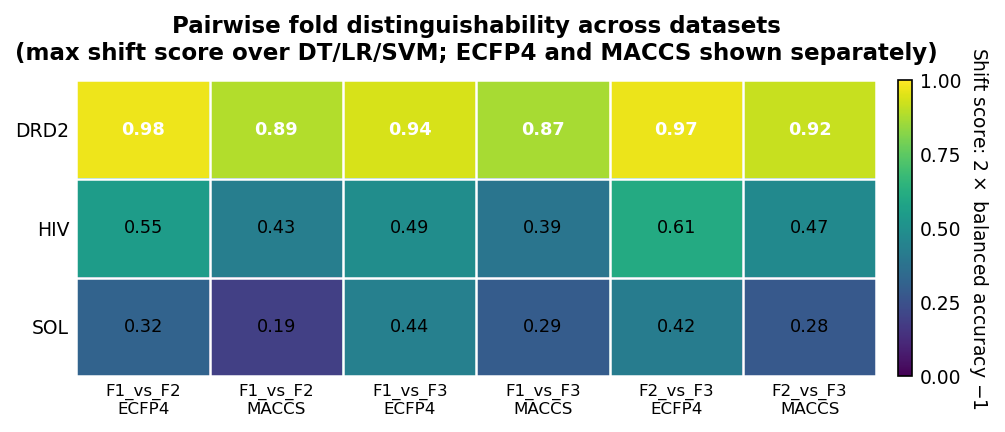

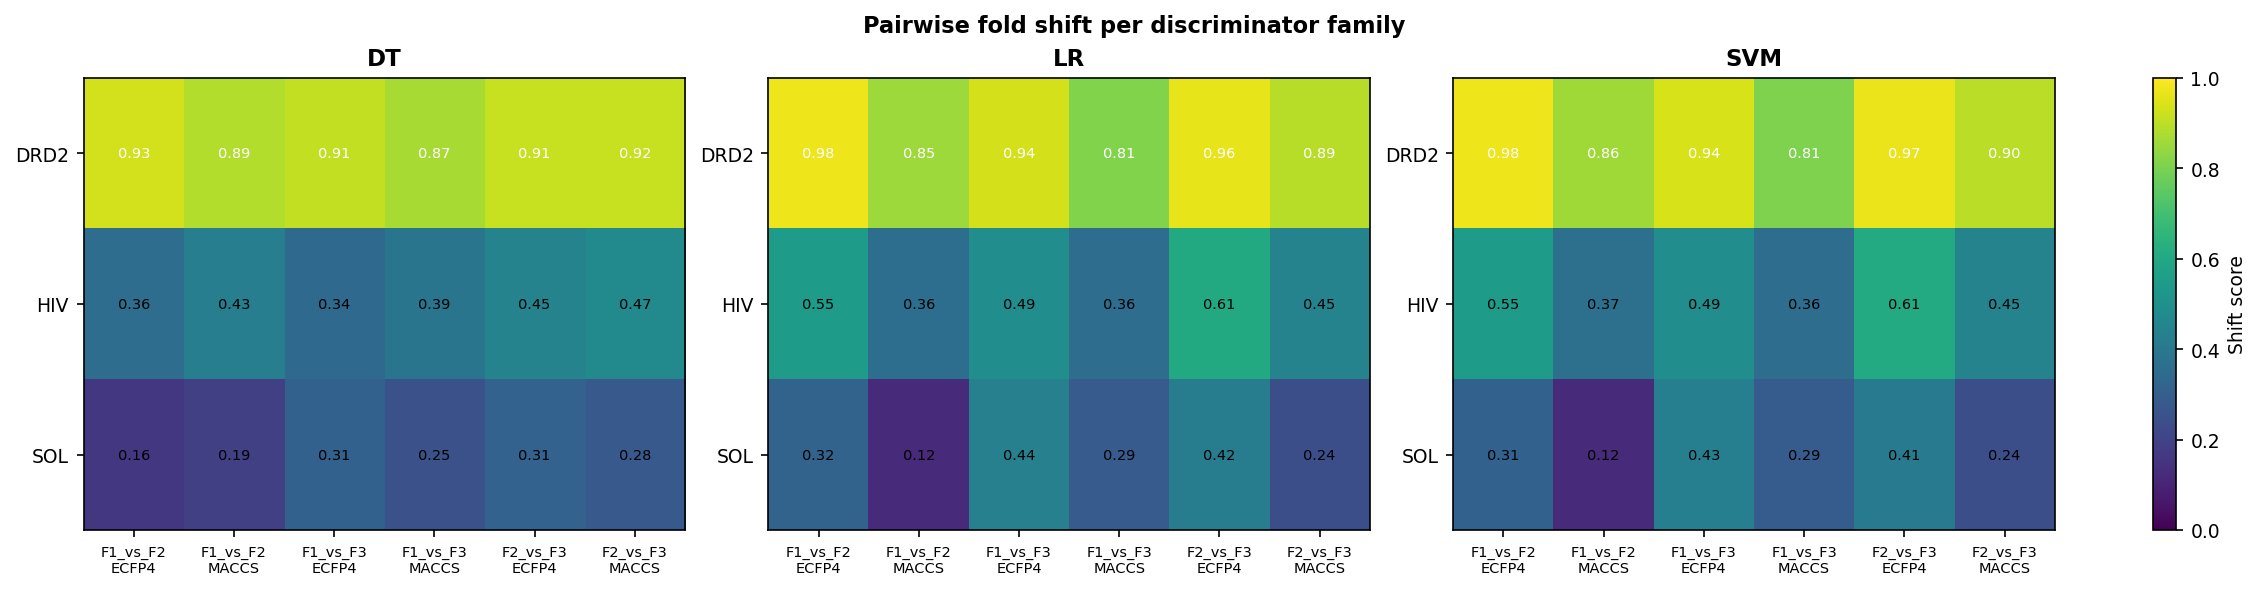

In [20]:
from textwrap import wrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure directory
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

df_shift_plot = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)
    .agg(
        shift_score_mean=("shift_score_01", "mean"),
        shift_score_max=("shift_score_01", "max"),
    )
)

SHIFT_AGG_COL = "shift_score_max"

df_shift_plot["column"] = (
    df_shift_plot["pair"] + "\n" + df_shift_plot["fingerprint"].str.upper()
)

shift_mat = (
    df_shift_plot
    .pivot(index="dataset", columns="column", values=SHIFT_AGG_COL)
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in shift_mat.columns:
            ordered_cols.append(col)

shift_mat = shift_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = shift_mat.shape

fig_width = max(6.8, 1.0 * n_cols)
fig_height = max(2.6, 0.55 * n_rows + 1.3)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Mask missing values, if any
data = np.ma.masked_invalid(shift_mat.values.astype(float))

cmap = mpl.colormaps["viridis"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Pairwise fold distinguishability across datasets\n"
    "(max shift score over DT/LR/SVM; ECFP4 and MACCS shown separately)",
    pad=10,
    fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(shift_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in shift_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = shift_mat.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value >= 0.62 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                fontweight="bold" if value >= 0.80 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    r"Shift score: $2 \times$ balanced accuracy $- 1$",
    rotation=270,
    labelpad=14,
)

cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(length=0)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.pdf",
    bbox_inches="tight",
)

plt.show()

# Per-model shift heatmaps (one panel per discriminator family)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

for ax, model_name in zip(axes, ["DT", "LR", "SVM"]):
    sub = (
        df_search_cv
        .query("fingerprint in @PLOT_FPS and model == @model_name")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
        .mean()
    )
    sub["column"] = sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    mat = sub.pivot(index="dataset", columns="column", values="shift_score_01").reindex(DATASETS)
    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    im = ax.imshow(
        np.ma.masked_invalid(mat.values.astype(float)),
        vmin=0, vmax=1, cmap=cmap, aspect="auto", interpolation="nearest",
    )
    ax.set_title(model_name, fontweight="bold")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=0, fontsize=7)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([d.upper() for d in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if v >= 0.62 else "black")

fig.colorbar(im, ax=axes, fraction=0.02, label="Shift score")
fig.suptitle("Pairwise fold shift per discriminator family", fontweight="bold", y=1.05)
fig.savefig(FIG_ROOT / "shift_heatmap_per_model.png", dpi=600, bbox_inches="tight")
plt.show()

## Fold-Aware List A vs List B Feature Overlap

Lo shift coinvolge le stesse feature del modello di attività?

In [21]:


PLOT_FPS = ["ecfp4", "maccs"]
OVERLAP_K = 20
LISTB_SOURCE = "same_search_cv"

PAIR_TO_OUTER_FOLD = {
    "F1_vs_F2": 1,
    "F1_vs_F3": 2,
    "F2_vs_F3": 3,
}


def top_features_from_listB(
    df_b: pd.DataFrame,
    dataset: str,
    pair: str,
    model: str,
    fingerprint: str,
    source: str,
    k: int,
) -> set:
    """
    Top-k shift/discriminator features for one dataset-pair-model-fingerprint.
    """
    sub = df_b[
        (df_b["dataset"] == dataset)
        & (df_b["pair"] == pair)
        & (df_b["model"] == model)
        & (df_b["fingerprint"] == fingerprint)
        & (df_b["source"] == source)
    ].copy()

    if sub.empty:
        return set()

    sub = sub.sort_values("rank", ascending=True)

    return set(sub.head(k)["feature_idx"].astype(int))


def top_features_listA_by_protocol_and_fold(
    df_a: pd.DataFrame,
    dataset: str,
    model: str,
    fingerprint: str,
    protocol: str,
    fold: int,
    k: int,
) -> set:
    """
    Top-k activity features for one dataset-model-fingerprint-protocol-fold.

    This aligns List A with the same outer fold corresponding to the List B pair:
        F1_vs_F2 -> fold 1
        F1_vs_F3 -> fold 2
        F2_vs_F3 -> fold 3
    """
    sub = df_a[
        (df_a["dataset"] == dataset)
        & (df_a["model"] == model)
        & (df_a["fingerprint"] == fingerprint)
        & (df_a["protocol"].astype(str).str.lower().str.contains(protocol.lower()))
        & (df_a["fold"].astype(int) == int(fold))
    ].copy()

    if sub.empty:
        return set()

    agg = (
        sub.groupby("feature_idx", as_index=False)["activity_importance"]
        .mean()
        .sort_values("activity_importance", ascending=False)
    )

    return set(agg.head(k)["feature_idx"].astype(int))


overlap_rows = []

PROTOCOLS = ["OOD holdout", "Random shuffle"]

PROTOCOL_SHORT = {
    "OOD holdout": "ood",
    "Random shuffle": "random",
}

for dataset in DATASETS:
    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"
        outer_fold = PAIR_TO_OUTER_FOLD[pair_name]

        for fp in PLOT_FPS:
            for model in ["DT", "LR", "SVM"]:

                b_features = top_features_from_listB(
                    df_b=df_listB,
                    dataset=dataset,
                    pair=pair_name,
                    model=model,
                    fingerprint=fp,
                    source=LISTB_SOURCE,
                    k=OVERLAP_K,
                )

                if not b_features:
                    continue

                for protocol in PROTOCOLS:
                    a_features = top_features_listA_by_protocol_and_fold(
                        df_a=df_listA,
                        dataset=dataset,
                        model=model,
                        fingerprint=fp,
                        protocol=protocol,
                        fold=outer_fold,
                        k=OVERLAP_K,
                    )

                    if not a_features:
                        continue

                    common_features = a_features & b_features
                    overlap = len(common_features) / OVERLAP_K

                    overlap_rows.append({
                        "dataset": dataset,
                        "pair": pair_name,
                        "outer_fold": outer_fold,
                        "fingerprint": fp,
                        "model": model,
                        "activity_protocol": PROTOCOL_SHORT[protocol],
                        "k": OVERLAP_K,
                        "overlap": overlap,
                        "n_overlap": len(common_features),
                        "overlap_features": json.dumps(sorted(list(common_features))),
                    })

df_overlap = pd.DataFrame(overlap_rows)

df_overlap.to_csv(
    OUT_ROOT / f"cross_dataset_listA_listB_overlap_by_protocol_foldaware_top{OVERLAP_K}.csv",
    index=False,
)

display(df_overlap.head(12))

,dataset,pair,outer_fold,fingerprint,model,activity_protocol,k,overlap,n_overlap,overlap_features
0,drd2,F1_vs_F2,1,ecfp4,DT,ood,20,0.00,0,[]
1,drd2,F1_vs_F2,1,ecfp4,DT,random,20,0.00,0,[]
2,drd2,F1_vs_F2,1,ecfp4,LR,ood,20,0.00,0,[]
3,drd2,F1_vs_F2,1,ecfp4,LR,random,20,0.00,0,[]
4,drd2,F1_vs_F2,1,ecfp4,SVM,ood,20,0.05,1,[1480]
5,drd2,F1_vs_F2,1,ecfp4,SVM,random,20,0.00,0,[]
6,drd2,F1_vs_F2,1,maccs,DT,ood,20,0.10,2,"[82, 152]"
7,drd2,F1_vs_F2,1,maccs,DT,random,20,0.20,4,"[42, 79, 80, 104]"
8,drd2,F1_vs_F2,1,maccs,LR,ood,20,0.15,3,"[24, 85, 99]"
9,drd2,F1_vs_F2,1,maccs,LR,random,20,0.15,3,"[85, 99, 122]"


## 15. Feature-Overlap Heatmaps by Validation Protocol

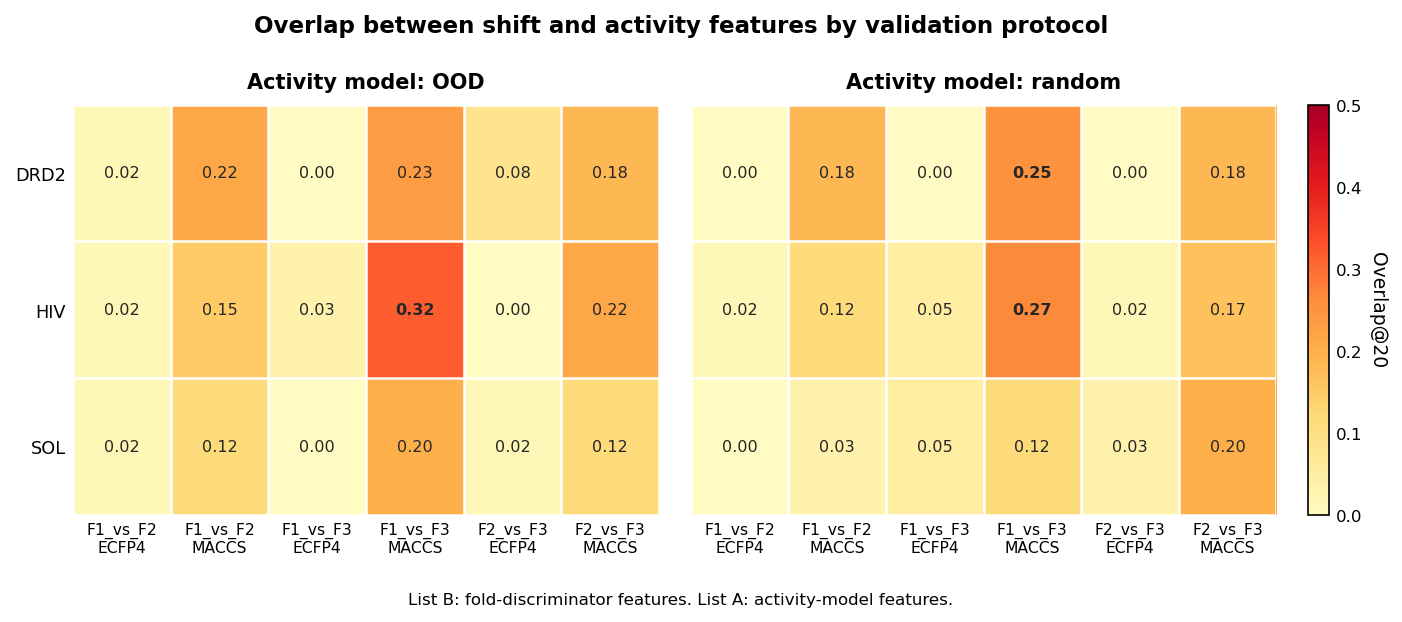

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.03, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        ordered_cols.append(f"{pair}\n{fp}")

protocol_labels = {
    "ood": "Activity model: OOD",
    "random": "Activity model: random",
}

vmin = 0.0
vmax = 0.50

fig = plt.figure(figsize=(10.8, 3.55))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.035],
    wspace=0.08,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]

cax = fig.add_subplot(gs[0, 2])

last_im = None

for ax, protocol in zip(axes, ["ood", "random"]):
    sub = (
        df_overlap
        .query("activity_protocol == @protocol")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
        .mean()
    )

    sub["column"] = (
        sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    )

    mat = (
        sub
        .pivot(index="dataset", columns="column", values="overlap")
        .reindex(DATASETS)
    )

    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    data = np.ma.masked_invalid(mat.values.astype(float))

    last_im = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        protocol_labels[protocol],
        fontweight="bold",
        pad=8,
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=0, ha="center")

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels([d.upper() for d in mat.index])

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)

    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]

            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7.7,
                    color="0.15",
                    fontweight="bold" if v >= 0.25 else "normal",
                )

axes[1].tick_params(labelleft=False)

cbar = fig.colorbar(
    last_im,
    cax=cax,
)

cbar.set_label(
    f"Overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=12,
)

cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.ax.tick_params(length=0, labelsize=8)

fig.suptitle(
    "Overlap between shift and activity features by validation protocol",
    fontweight="bold",
    y=1.05,
    fontsize=11,
)

fig.text(
    0.5,
    -0.035,
    "List B: fold-discriminator features. List A: activity-model features.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.pdf",
    bbox_inches="tight",
)

plt.show()

## Global Feature-Overlap Heatmap

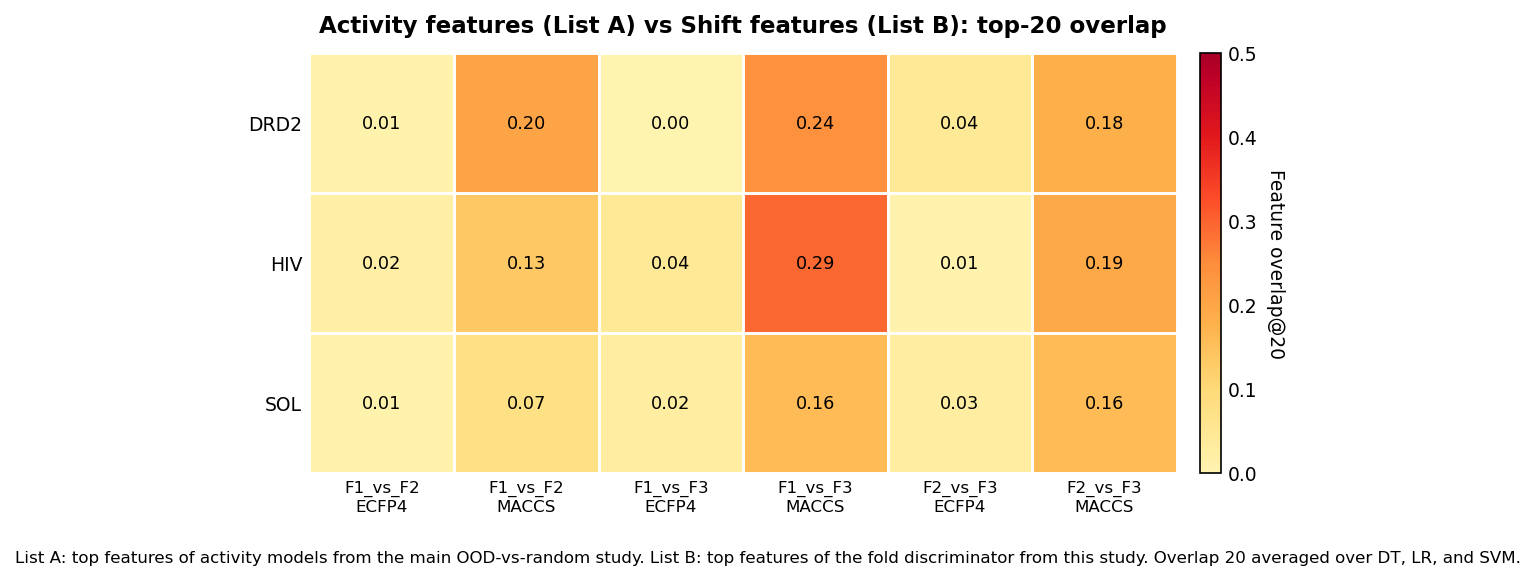

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

df_overlap_plot = (
    df_overlap
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
    .mean()
)

df_overlap_plot["column"] = (
    df_overlap_plot["pair"] + "\n" + df_overlap_plot["fingerprint"].str.upper()
)

overlap_mat = (
    df_overlap_plot
    .pivot(index="dataset", columns="column", values="overlap")
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in overlap_mat.columns:
            ordered_cols.append(col)

overlap_mat = overlap_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = overlap_mat.shape

fig, ax = plt.subplots(figsize=(7.2, 3.6))

data = np.ma.masked_invalid(overlap_mat.values.astype(float))

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.08, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

vmax = 0.50

im = ax.imshow(
    data,
    vmin=0,
    vmax=vmax,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Activity features (List A) vs Shift features (List B): top-20 overlap",
    pad=10, fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(overlap_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in overlap_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = overlap_mat.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="black",
                fontweight="bold" if value >= 0.30 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    f"Feature overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=13,
)

cbar.set_ticks(np.linspace(0, vmax, 6))
cbar.ax.tick_params(length=0)

fig.text(
    0.5, -0.03,
    "List A: top features of activity models from the main OOD-vs-random study. "
    "List B: top features of the fold discriminator from this study. "
    f"Overlap {OVERLAP_K} averaged over DT, LR, and SVM.",
    ha="center", va="top", fontsize=8,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.pdf",
    bbox_inches="tight",
)

plt.show()

## Load OOD-vs-Random Per-Fold Protocol Results



In [24]:
OOD_CROSS_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
)

PROTOCOL_PATH = OOD_CROSS_DIR / "cross_dataset_protocol_per_fold.csv"

if not PROTOCOL_PATH.exists():
    raise FileNotFoundError(
        f"Missing protocol table from OOD-vs-random study: {PROTOCOL_PATH}"
    )

df_protocol_per_fold = pd.read_csv(PROTOCOL_PATH).copy()
df_protocol_per_fold = df_protocol_per_fold[
    df_protocol_per_fold["dataset"].isin(DATASETS_MAIN)
].copy()

assert "kdr" not in set(df_protocol_per_fold["dataset"]), (
    "KDR should not enter the main shift-vs-protocol analysis."
)

print("protocol_per_fold columns:")
print(df_protocol_per_fold.columns.tolist())

display(df_protocol_per_fold.head())

protocol_per_fold columns:
['dataset', 'dataset_label', 'model', 'model_short', 'fingerprint', 'protocol', 'fold', 'inner_pr_auc', 'inner_train_pr_auc', 'train_pr_auc', 'test_pr_auc', 'inner_test_gap', 'train_test_gap', 'model_order', 'fingerprint_order', 'protocol_order', 'dataset_order']


,dataset,dataset_label,model,model_short,fingerprint,protocol,fold,inner_pr_auc,inner_train_pr_auc,train_pr_auc,test_pr_auc,inner_test_gap,train_test_gap,model_order,fingerprint_order,protocol_order,dataset_order
0,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,1,0.849198,0.931822,0.9496,0.6620,0.187198,0.2876,0,0,0,0
1,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,2,0.697409,0.882575,0.7683,0.8022,-0.104791,-0.0339,0,0,0,0
2,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,3,0.731996,0.945777,0.9029,0.7052,0.026796,0.1977,0,0,0,0
3,drd2,DRD2,Decision Tree,DT,ECFP4,Random shuffle,1,0.906735,0.955275,0.9339,0.6687,0.238035,0.2652,0,0,1,0
4,drd2,DRD2,Decision Tree,DT,ECFP4,Random shuffle,2,0.830900,0.931783,0.8539,0.7398,0.091100,0.1141,0,0,1,0


## Pairwise Shift vs OOD-vs-Random Protocol Gap

In [25]:
def infer_fold_column(df: pd.DataFrame) -> str:
    candidates = ["fold", "outer_fold", "fold_id", "test_fold"]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not infer fold column. "
        f"Available columns: {df.columns.tolist()}"
    )

In [26]:
# Pairwise shift vs OOD-vs-random validation gap
#
# Two complementary gaps, both built from protocol_per_fold.csv:
#
# 1. optimism_gap_diff:
#       optimism_gap_random  =  inner_pr_auc_random  - test_pr_auc_random
#       optimism_gap_ood     =  inner_pr_auc_ood     - test_pr_auc_ood
#       optimism_gap_diff    =  optimism_gap_random  - optimism_gap_ood
#    Positive value: random validation is more optimistic than OOD validation.
#
# 2. test_gap:
#       test_gap = test_pr_auc_ood - test_pr_auc_random
#    Positive value: OOD-selected model beats random-selected model on the real OOD test set.
# ============================================================

PLOT_FPS = ["ecfp4", "maccs"]

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

# Shift table (averaged over fingerprints and models for the overview)
df_shift_pair = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .loc[lambda d: d["dataset"].isin(DATASETS_MAIN)]
    .groupby(["dataset", "pair"], as_index=False)
    .agg(
        shift_score_mean=("shift_score_01", "mean"),
        shift_score_max=("shift_score_01", "max"),
    )
)

# Main x-axis score: best discriminator across model/fingerprint combinations.
df_shift_pair["shift_score_01"] = df_shift_pair["shift_score_max"]

# Build the per-fold protocol table
df_gap_raw = df_protocol_per_fold.copy()
df_gap_raw["fingerprint_norm"] = df_gap_raw["fingerprint"].astype(str).str.lower()
df_gap_raw["model_short_norm"] = df_gap_raw["model_short"].astype(str).str.upper()

df_gap_raw = df_gap_raw[
    df_gap_raw["fingerprint_norm"].isin(PLOT_FPS)
    & df_gap_raw["model_short_norm"].isin(["DT", "LR", "SVM"])
].copy()
df_gap_raw["protocol_norm"] = df_gap_raw["protocol"].astype(str).str.lower()

def protocol_family(x: str) -> str:
    if "random" in x:
        return "random"
    if "ood" in x or "holdout" in x:
        return "ood"
    return x

df_gap_raw["protocol_family"] = df_gap_raw["protocol_norm"].map(protocol_family)
df_gap_raw = df_gap_raw[df_gap_raw["protocol_family"].isin(["random", "ood"])].copy()

df_gap_raw["outer_fold"] = df_gap_raw["fold"].astype(int)
df_gap_raw["pair"] = df_gap_raw["outer_fold"].map(OUTER_FOLD_TO_PAIR)

# Per-fold optimism gap, per protocol
df_gap_raw["optimism_gap"] = df_gap_raw["inner_pr_auc"] - df_gap_raw["test_pr_auc"]

df_gap_agg = (
    df_gap_raw
    .groupby(["dataset", "pair", "protocol_family"], as_index=False)
    .agg(
        inner_pr_auc=("inner_pr_auc", "mean"),
        test_pr_auc=("test_pr_auc", "mean"),
        optimism_gap=("optimism_gap", "mean"),
    )
)

# Pivot random vs OOD
df_gap_pivot = df_gap_agg.pivot_table(
    index=["dataset", "pair"],
    columns="protocol_family",
    values=["inner_pr_auc", "test_pr_auc", "optimism_gap"],
).reset_index()

df_gap_pivot.columns = [
    "_".join(c).rstrip("_") if isinstance(c, tuple) else c
    for c in df_gap_pivot.columns
]

df_gap_pivot["optimism_gap_diff"] = (
    df_gap_pivot["optimism_gap_random"] - df_gap_pivot["optimism_gap_ood"]
)
df_gap_pivot["test_gap"] = (
    df_gap_pivot["test_pr_auc_ood"] - df_gap_pivot["test_pr_auc_random"]
)

df_gap_pair = df_gap_pivot[[
    "dataset", "pair",
    "inner_pr_auc_random", "inner_pr_auc_ood",
    "test_pr_auc_random",  "test_pr_auc_ood",
    "optimism_gap_random", "optimism_gap_ood",
    "optimism_gap_diff",
    "test_gap",
]].copy()

df_shift_gap = df_shift_pair.merge(df_gap_pair, on=["dataset", "pair"], how="inner")

df_shift_gap = df_shift_gap[df_shift_gap["dataset"].isin(DATASETS_MAIN)].copy()

assert "kdr" not in set(df_shift_gap["dataset"]), (
    "KDR should not enter the main shift-vs-protocol analysis."
)

expected_rows = len(DATASETS_MAIN) * len(PAIRS)
assert len(df_shift_gap) == expected_rows, (
    f"Expected {expected_rows} rows: "
    f"{len(DATASETS_MAIN)} datasets × {len(PAIRS)} fold pairs. "
    f"Got {len(df_shift_gap)}."
)

df_shift_gap.to_csv(
    OUT_ROOT / "cross_dataset_pairwise_shift_vs_protocol_gap.csv",
    index=False,
)

display(df_shift_gap.round(3))

,dataset,pair,shift_score_mean,shift_score_max,shift_score_01,inner_pr_auc_random,inner_pr_auc_ood,test_pr_auc_random,test_pr_auc_ood,optimism_gap_random,optimism_gap_ood,optimism_gap_diff,test_gap
0,drd2,F1_vs_F2,0.913,0.977,0.977,0.904,0.834,0.648,0.652,0.257,0.182,0.075,0.005
1,drd2,F1_vs_F3,0.879,0.941,0.941,0.851,0.698,0.804,0.806,0.047,-0.108,0.155,0.002
2,drd2,F2_vs_F3,0.926,0.971,0.971,0.879,0.719,0.750,0.735,0.128,-0.016,0.144,-0.016
3,hiv,F1_vs_F2,0.437,0.554,0.554,0.298,0.114,0.127,0.112,0.171,0.002,0.169,-0.015
4,hiv,F1_vs_F3,0.404,0.492,0.492,0.297,0.175,0.074,0.081,0.224,0.094,0.130,0.008
5,hiv,F2_vs_F3,0.506,0.610,0.610,0.394,0.162,0.033,0.033,0.361,0.129,0.232,-0.000
6,sol,F1_vs_F2,0.203,0.318,0.318,0.502,0.446,0.452,0.455,0.050,-0.009,0.058,0.002
7,sol,F1_vs_F3,0.334,0.436,0.436,0.520,0.468,0.451,0.445,0.070,0.023,0.046,-0.006
8,sol,F2_vs_F3,0.317,0.419,0.419,0.524,0.461,0.416,0.428,0.108,0.033,0.075,0.012


## Scatter Plot: Shift Score vs OOD Test Benefit

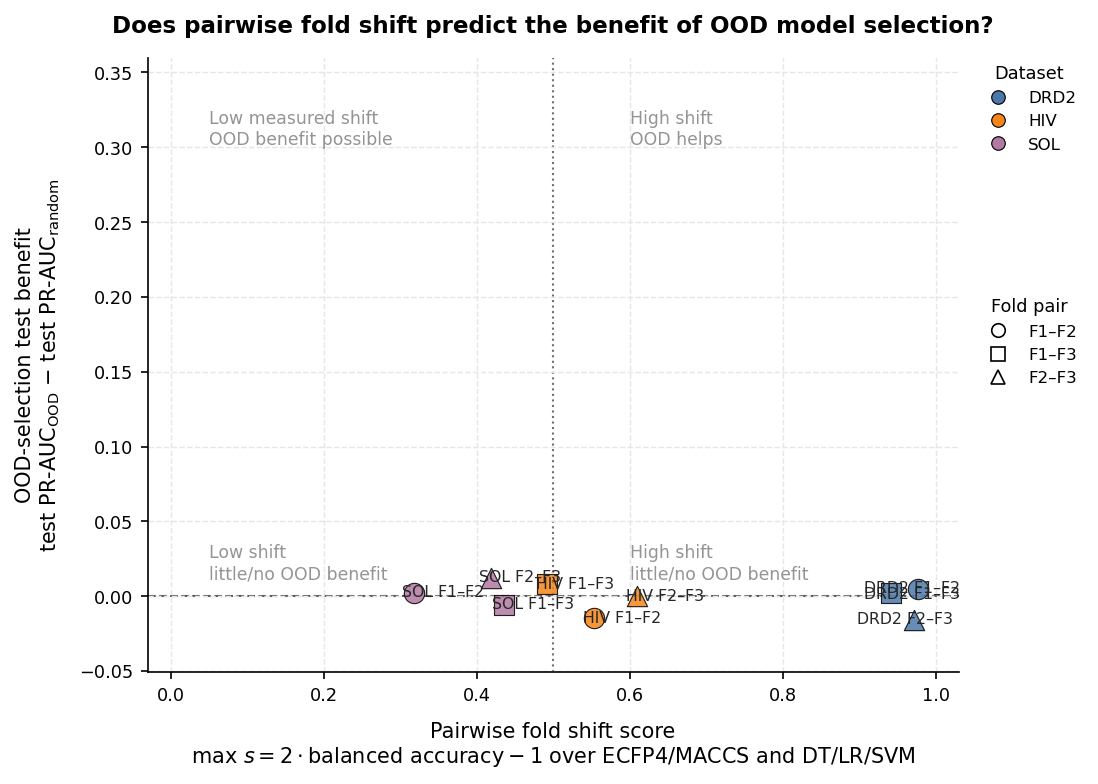

In [27]:
# Plot: pairwise fold shift vs OOD-selection test benefit

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from adjustText import adjust_text

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

df_shift_gap = df_shift_gap[df_shift_gap["dataset"].isin(DATASETS_MAIN)].copy()

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

# Positive value = OOD-based model selection improves final OOD test PR-AUC.
GAP_COL = "test_gap"

GAP_LABEL = (
    "OOD-selection test benefit\n"
    r"test PR-AUC$_{\mathrm{OOD}}$ $-$ test PR-AUC$_{\mathrm{random}}$"
)

SHIFT_THRESHOLD = 0.50

markers = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

dataset_colors = {
    "DRD2": "#4C78A8",
    "HIV":  "#F58518",
    "SOL":  "#B279A2",
}

fig, ax = plt.subplots(figsize=(7.4, 5.3))

texts = []

for _, row in df_shift_gap.iterrows():
    dataset = row["dataset"].upper()
    pair = row["pair"]

    x = row["shift_score_01"]
    y = row[GAP_COL]

    ax.scatter(
        x,
        y,
        s=95,
        marker=markers.get(pair, "o"),
        facecolor=dataset_colors.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.55,
        alpha=0.85,
        zorder=3,
    )

    texts.append(
        ax.text(
            x,
            y,
            f"{dataset} {pair.replace('_vs_', '–')}",
            fontsize=7.6,
            color="0.15",
            zorder=4,
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.25, 0.35),
    force_static=(0.15, 0.25),
    only_move={"text": "xy"},
)

ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1,
)

ax.axvline(
    SHIFT_THRESHOLD,
    color="0.25",
    linestyle=":",
    linewidth=1.0,
    alpha=0.75,
    zorder=1,
)

ax.set_xlim(-0.03, 1.03)

y_min = min(-0.04, df_shift_gap[GAP_COL].min() - 0.035)
y_max = max(0.36, df_shift_gap[GAP_COL].max() + 0.035)
ax.set_ylim(y_min, y_max)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

quad_style = dict(
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    y_max - 0.035,
    "Low measured shift\nOOD benefit possible",
    **quad_style,
)

ax.text(
    0.60,
    y_max - 0.035,
    "High shift\nOOD helps",
    **quad_style,
)

ax.text(
    0.60,
    0.035,
    "High shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    0.035,
    "Low shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Pairwise fold shift score\n"
    r"max $s = 2 \cdot \mathrm{balanced\ accuracy} - 1$ over ECFP4/MACCS and DT/LR/SVM",
    labelpad=8,
)

ax.set_ylabel(GAP_LABEL, labelpad=8)

ax.set_title(
    "Does pairwise fold shift predict the benefit of OOD model selection?",
    pad=12,
    fontweight="bold",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.55,
        markersize=6.5,
        label=dataset,
    )
    for dataset, color in dataset_colors.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=6.5,
        label=pair.replace("_vs_", "–"),
    )
    for pair, marker in markers.items()
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=False,
    borderaxespad=0.0,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.pdf",
    bbox_inches="tight",
)

plt.show()

# Final Interpretation and Methodological Takeaways

This notebook extends the original Lo-Hi Hi benchmark analysis by measuring the actual fold-to-fold distribution shift induced by the predefined Hi splits. Instead of relying only on the original ECFP4 Tanimoto novelty criterion, we use a classifier two-sample test: for each dataset, a discriminator is trained to distinguish molecules belonging to one fold subset from molecules belonging to another fold subset. If the discriminator can separate the two groups out-of-sample, then the corresponding folds have a measurable and generalizable distribution shift.

The main quantity reported in the figures is the **shift score**:

$$s = 2 \cdot \text{balanced accuracy} - 1 \in [0,1].$$

A value close to 0 means that two fold subsets are difficult to distinguish, while a value close to 1 means that they are almost perfectly separable. This is a normalized version of the proxy $\mathcal{A}$-distance used in the domain-adaptation literature. The notebook keeps the proxy $\mathcal{A}$-distance in the CSV outputs, but uses the shift score in plots because it is easier to interpret visually.

### Shift Profiles Across Datasets

The first result is that the four Hi datasets have very different fold-shift profiles:
* **DRD2:** Shows very high fold distinguishability across all fold pairs and fingerprints.
* **HIV:** Has an intermediate shift.
* **Sol:** Has the weakest shift, suggesting that its fold subsets are chemically more similar under the tested representations.
* **KDR:** Is a special case. The reconstructed test subsets have substantial SMILES overlap across folds, so its pairwise fold-discrimination scores must be interpreted with caution. The KDR diagnostic shows that a high-capacity Decision Tree cannot perfectly separate the reconstructed fold pairs because many molecules are shared across test files; in these cases, identical molecular features receive different fold labels in the two-sample task.

This means that the classifier two-sample test is not only measuring distribution shift; it also acts as a useful diagnostic for the fold construction itself. For DRD2, HIV, and Sol, the fold-discrimination task can be interpreted as a cleaner measure of fold-to-fold shift. For KDR, the analysis reveals that the reconstructed fold subsets are not fully disjoint, and this affects the interpretation of the shift score. KDR should therefore be discussed separately or with an explicit methodological note.

### Disconnecting Shift Severity from OOD Benefit

The second result is that a high fold-shift score alone does not necessarily imply that OOD-based validation will improve final test performance. DRD2 has very high fold distinguishability, but the OOD-vs-random test gap is close to zero. This suggests that the folds are chemically distinguishable, but the discriminating features may not be the same features that are most relevant for predicting activity. In contrast, KDR shows a large OOD-selection test benefit, although its shift analysis is complicated by fold overlap. HIV and Sol show lower or intermediate shift and little systematic OOD-selection benefit.

### Feature Overlap: List A vs. List B

For this reason, the notebook also compares two feature sets:
* **List B (Shift features):** Contains the most important features used by the fold discriminators, i.e., the features that characterize the shift.
* **List A (Activity features):** Contains the most important features used by the activity models from the main OOD-vs-random study.

The fold-aware overlap between List A and List B measures whether the features that separate folds are also used for activity prediction. This is the key mechanism-level analysis: if the shift features and activity features overlap strongly, then the distribution shift is more likely to affect model selection and generalization; if the overlap is low, the folds may be distinguishable without strongly affecting the learned activity signal.

### Conclusion

Overall, the analysis refines the interpretation of the Lo-Hi benchmark. The original Lo-Hi Hi split is methodologically meaningful because it enforces a practical novelty constraint based on ECFP4 Tanimoto similarity. However, Tanimoto novelty alone does not fully describe the effective difficulty of the split. Two datasets can both satisfy the Hi novelty condition while producing very different distribution-shift profiles, different feature-overlap patterns, and different benefits from OOD-based model selection.

The main methodological takeaway is therefore:

> **Lo-Hi provides a strong practical benchmark for Hit Identification, but the severity and relevance of the induced OOD shift should be measured explicitly. A classifier two-sample test gives a data-driven, model-aware estimate of fold distinguishability, while the List A vs List B overlap indicates whether the shift affects the same molecular features used for activity prediction.**

---

### Next Steps: LLM as a Chemical Interpreter

This motivates a natural next step: using an LLM not as an activity predictor, but as a chemical interpreter of the measured shift signature. The quantitative pipeline first identifies the fold-discriminating features, List B, and measures their overlap with the activity-model features, List A. The LLM can then be used downstream as a structured judge to interpret whether the List B features correspond to chemically meaningful patterns: scaffold-level signals such as ring systems, substitution patterns and chemotype differences, or more activity-relevant pharmacophoric signals such as hydrogen-bond donors/acceptors, aromatic centers, charged groups, or other interaction motifs. In this way, the LLM becomes an interpretation layer on top of the classifier two-sample test, not a replacement for the quantitative analysis.

This would close the methodological loop: the notebook first measures how distinguishable the folds are, then tests whether the shift features overlap with activity features, and finally uses the LLM to qualify the chemical meaning of that overlap. For DRD2 in particular, this could directly address the main anomaly observed in the analysis. DRD2 shows very high fold distinguishability but little or no OOD-selection test benefit. If the LLM analysis confirms that the dominant shift features are mostly scaffold or chemotype markers rather than pharmacophoric features used for activity prediction, this would provide a coherent explanation: the folds are chemically distinguishable, but the shift does not strongly affect the molecular evidence that the activity models rely on.

## Why Tanimoto distance is not enough

The Lo-Hi splitting criterion based on ECFP4 Tanimoto similarity is a strong and practical starting point for simulating hit identification. It enforces geometric novelty between train and test molecules and prevents the most obvious form of train-test similarity leakage. However, this criterion alone is incomplete: it measures **how far** two groups of molecules are in fingerprint space, but it does not tell us **where** this difference lies chemically, nor whether the difference affects the features that the activity model actually uses.

This distinction is important because not all distribution shifts are equally harmful. A dataset can show a strong fold-discrimination signal without necessarily producing a large drop in model performance. DRD2 is the clearest example: its fold subsets are highly distinguishable, yet OOD-based model selection does not substantially outperform random-shuffle model selection on the final test set. This suggests that a large part of the shift may be **benign**: the molecular scaffolds or chemotypes differ across folds, but the activity-relevant chemical evidence remains sufficiently shared for the model to generalize.

We can therefore distinguish two types of shift. A **benign shift** changes mostly the external scaffold, ring systems, or substitution patterns, while preserving the key activity-related motifs. In this case, the model may still transfer well across folds. A **harmful shift**, instead, affects the same molecular features that the model relies on to predict activity, such as pharmacophoric patterns, hydrogen-bond donors or acceptors, aromatic centers, charged groups, or other interaction-relevant motifs. In this second case, random validation can become misleading and OOD validation becomes much more important.

For this reason, the analysis needs to be **model-aware**. It is not enough to inspect structural distance alone. We need to compare the features that define the distribution shift with the features used for activity prediction. In this notebook, these are represented by two lists: **List B**, the fold-discriminating features learned by the classifier two-sample test, and **List A**, the activity-predictive features learned in the main OOD-vs-random study. If List A and List B have low overlap, the shift is visible but may not be strongly relevant for the prediction task. If they overlap strongly, the split is more likely to be genuinely challenging for the model, because the distribution shift affects the same molecular evidence used for activity prediction.

This also defines the most appropriate role for the LLM. The LLM should not be used as a black-box activity predictor or as an oracle. Its role is instead interpretative: given the mathematical features isolated by the quantitative models, it can help translate them into chemical language. In practice, the LLM can inspect the relevant List B features, the List A ∩ List B overlap, representative molecules, and associated descriptors, and then assess whether the shift corresponds mainly to scaffold-level variation or to activity-relevant pharmacophoric changes. This makes the LLM a chemical interpretation layer on top of the measured shift, rather than a replacement for the classifier two-sample test or the activity models.

##  Predictive-shift overlap vs OOD validation usefulness

 Question:
   Does OOD validation help more when the fold shift affects the same
   features used by the activity model?

In [28]:
# ============================================================
# Predictive-shift overlap vs OOD validation usefulness
#
# Question:
#   Does OOD validation help more when the fold shift affects the same
#   features used by the activity model?
#
# x-axis:
#   List A vs List B overlap
#   List A = activity-model top features
#   List B = fold-discriminator top features
#
# y-axis:
#   1. validation optimism reduction:
#        optimism_gap_random - optimism_gap_ood
#
#   2. final OOD test benefit:
#        test_pr_auc_ood - test_pr_auc_random
#
# Interpretation:
#   If overlap is low but optimism reduction is high, OOD validation is more
#   realistic but does not necessarily improve final model selection.
#
#   If overlap is high and test benefit is positive, the chemically induced
#   shift is also predictive-relevant, so OOD validation becomes useful.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

DATASET_COLOR = {
    "drd2": "#4C78A8",
    "hiv": "#F58518",
    "sol": "#B279A2",
}

MODEL_MARKER = {
    "DT": "o",
    "LR": "s",
    "SVM": "^",
}

FP_ALPHA = {
    "ecfp4": 0.90,
    "maccs": 0.60,
}


def protocol_family(x: str) -> str:
    x = str(x).lower()

    if "random" in x:
        return "random"

    if "ood" in x or "holdout" in x:
        return "ood"

    return x


def build_predictive_shift_overlap_table(
    df_overlap: pd.DataFrame,
    df_protocol_per_fold: pd.DataFrame,
    df_search_cv: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build model/fingerprint-level table linking:

    - List A vs List B overlap;
    - validation optimism reduction;
    - final OOD test benefit;
    - pairwise fold shift score.

    One row corresponds to:
        dataset, pair, fingerprint, model
    """

    required_overlap_cols = [
        "dataset", "pair", "fingerprint", "model",
        "activity_protocol", "overlap",
    ]

    missing = [c for c in required_overlap_cols if c not in df_overlap.columns]
    if missing:
        raise ValueError(f"Missing columns in df_overlap: {missing}")

    ov = df_overlap.copy()

    ov["fingerprint_norm"] = ov["fingerprint"].astype(str).str.lower()
    ov["model_norm"] = ov["model"].astype(str).str.upper()
    ov["activity_protocol_norm"] = ov["activity_protocol"].astype(str).str.lower()

    ov = ov[
        ov["dataset"].isin(DATASETS_MAIN)
        & ov["fingerprint_norm"].isin(PLOT_FPS)
        & ov["model_norm"].isin(["DT", "LR", "SVM"])
    ].copy()

    ov = (
        ov
        .groupby(
            [
                "dataset",
                "pair",
                "fingerprint_norm",
                "model_norm",
                "activity_protocol_norm",
            ],
            as_index=False,
        )
        .agg(
            overlap_mean=("overlap", "mean"),
            overlap_std=("overlap", "std"),
            n_overlap_rows=("overlap", "size"),
        )
    )

    ov_pivot = ov.pivot_table(
        index=["dataset", "pair", "fingerprint_norm", "model_norm"],
        columns="activity_protocol_norm",
        values="overlap_mean",
    ).reset_index()

    ov_pivot.columns.name = None

    if "ood" not in ov_pivot.columns:
        ov_pivot["ood"] = np.nan

    if "random" not in ov_pivot.columns:
        ov_pivot["random"] = np.nan

    ov_pivot = ov_pivot.rename(
        columns={
            "fingerprint_norm": "fingerprint",
            "model_norm": "model",
            "ood": "overlap_ood",
            "random": "overlap_random",
        }
    )

    ov_pivot["overlap_mean"] = ov_pivot[
        ["overlap_ood", "overlap_random"]
    ].mean(axis=1)

    ov_pivot["overlap_delta_ood_minus_random"] = (
        ov_pivot["overlap_ood"] - ov_pivot["overlap_random"]
    )

    # --------------------------------------------------------
    # Build protocol gap at dataset/pair/fingerprint/model level
    # --------------------------------------------------------
    required_protocol_cols = [
        "dataset", "fold", "fingerprint", "model_short",
        "protocol", "inner_pr_auc", "test_pr_auc",
    ]

    missing = [c for c in required_protocol_cols if c not in df_protocol_per_fold.columns]
    if missing:
        raise ValueError(f"Missing columns in df_protocol_per_fold: {missing}")

    gap = df_protocol_per_fold.copy()

    gap = gap[gap["dataset"].isin(DATASETS_MAIN)].copy()
    gap["fingerprint"] = gap["fingerprint"].astype(str).str.lower()
    gap["model"] = gap["model_short"].astype(str).str.upper()
    gap["protocol_family"] = gap["protocol"].map(protocol_family)

    gap = gap[
        gap["fingerprint"].isin(PLOT_FPS)
        & gap["model"].isin(["DT", "LR", "SVM"])
        & gap["protocol_family"].isin(["ood", "random"])
    ].copy()

    gap["outer_fold"] = gap["fold"].astype(int)
    gap["pair"] = gap["outer_fold"].map(OUTER_FOLD_TO_PAIR)

    gap["optimism_gap"] = gap["inner_pr_auc"] - gap["test_pr_auc"]

    gap_agg = (
        gap
        .groupby(
            ["dataset", "pair", "fingerprint", "model", "protocol_family"],
            as_index=False,
        )
        .agg(
            inner_pr_auc=("inner_pr_auc", "mean"),
            test_pr_auc=("test_pr_auc", "mean"),
            optimism_gap=("optimism_gap", "mean"),
        )
    )

    gap_pivot = gap_agg.pivot_table(
        index=["dataset", "pair", "fingerprint", "model"],
        columns="protocol_family",
        values=["inner_pr_auc", "test_pr_auc", "optimism_gap"],
    ).reset_index()

    gap_pivot.columns = [
        "_".join(c).rstrip("_") if isinstance(c, tuple) else c
        for c in gap_pivot.columns
    ]

    needed = [
        "inner_pr_auc_ood", "inner_pr_auc_random",
        "test_pr_auc_ood", "test_pr_auc_random",
        "optimism_gap_ood", "optimism_gap_random",
    ]

    missing_needed = [c for c in needed if c not in gap_pivot.columns]
    if missing_needed:
        raise ValueError(f"Missing columns after pivot: {missing_needed}")

    gap_pivot["optimism_gap_diff"] = (
        gap_pivot["optimism_gap_random"] - gap_pivot["optimism_gap_ood"]
    )

    gap_pivot["test_gap"] = (
        gap_pivot["test_pr_auc_ood"] - gap_pivot["test_pr_auc_random"]
    )

    # --------------------------------------------------------
    # Add model/fingerprint-specific shift score
    # --------------------------------------------------------
    shift = df_search_cv.copy()

    shift = shift[shift["dataset"].isin(DATASETS_MAIN)].copy()
    shift["fingerprint"] = shift["fingerprint"].astype(str).str.lower()
    shift["model"] = shift["model"].astype(str).str.upper()

    shift = shift[
        shift["fingerprint"].isin(PLOT_FPS)
        & shift["model"].isin(["DT", "LR", "SVM"])
    ].copy()

    shift_agg = (
        shift
        .groupby(["dataset", "pair", "fingerprint", "model"], as_index=False)
        .agg(
            shift_score_01=("shift_score_01", "mean"),
            proxy_A_distance=("proxy_A_distance", "mean"),
            cv_balanced_accuracy_mean=("cv_balanced_accuracy_mean", "mean"),
        )
    )

    out = (
        ov_pivot
        .merge(
            gap_pivot,
            on=["dataset", "pair", "fingerprint", "model"],
            how="inner",
        )
        .merge(
            shift_agg,
            on=["dataset", "pair", "fingerprint", "model"],
            how="left",
        )
    )

    out["dataset_label"] = (
        out["dataset"]
        .map(DATASET_LABELS)
        .fillna(out["dataset"].astype(str).str.upper())
    )

    out = out.sort_values(
        ["dataset", "pair", "fingerprint", "model"]
    ).reset_index(drop=True)

    return out


df_predictive_shift = build_predictive_shift_overlap_table(
    df_overlap=df_overlap,
    df_protocol_per_fold=df_protocol_per_fold,
    df_search_cv=df_search_cv,
)

out_path = OUT_ROOT / f"cross_dataset_predictive_shift_overlap_vs_protocol_gap_top{OVERLAP_K}.csv"
df_predictive_shift.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
display(df_predictive_shift.round(3).head(20))

Saved: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_predictive_shift_overlap_vs_protocol_gap_top20.csv


,dataset,pair,fingerprint,model,overlap_ood,overlap_random,overlap_mean,overlap_delta_ood_minus_random,inner_pr_auc_ood,inner_pr_auc_random,optimism_gap_ood,optimism_gap_random,test_pr_auc_ood,test_pr_auc_random,optimism_gap_diff,test_gap,shift_score_01,proxy_A_distance,cv_balanced_accuracy_mean,dataset_label
0,drd2,F1_vs_F2,ecfp4,DT,0.00,0.00,0.000,0.00,0.849,0.907,0.187,0.238,0.662,0.669,0.051,-0.007,0.931,1.862,0.966,DRD2
1,drd2,F1_vs_F2,ecfp4,LR,0.00,0.00,0.000,0.00,0.863,0.942,0.179,0.277,0.684,0.665,0.099,0.019,0.977,1.953,0.988,DRD2
2,drd2,F1_vs_F2,ecfp4,SVM,0.05,0.00,0.025,0.05,0.834,0.935,0.182,0.276,0.652,0.659,0.094,-0.007,0.977,1.953,0.988,DRD2
3,drd2,F1_vs_F2,maccs,DT,0.10,0.20,0.150,-0.10,0.843,0.891,0.216,0.288,0.626,0.603,0.071,0.023,0.885,1.770,0.943,DRD2
4,drd2,F1_vs_F2,maccs,LR,0.15,0.15,0.150,0.00,0.804,0.878,0.164,0.244,0.640,0.634,0.080,0.006,0.853,1.706,0.927,DRD2
5,drd2,F1_vs_F2,maccs,SVM,0.40,0.20,0.300,0.20,0.810,0.873,0.161,0.217,0.649,0.656,0.056,-0.007,0.857,1.715,0.929,DRD2
6,drd2,F1_vs_F3,ecfp4,DT,0.00,0.00,0.000,0.00,0.697,0.831,-0.105,0.091,0.802,0.740,0.196,0.062,0.909,1.819,0.955,DRD2
7,drd2,F1_vs_F3,ecfp4,LR,0.00,0.00,0.000,0.00,0.663,0.887,-0.177,0.047,0.840,0.840,0.224,0.000,0.937,1.874,0.968,DRD2
8,drd2,F1_vs_F3,ecfp4,SVM,0.00,0.00,0.000,0.00,0.681,0.881,-0.166,0.030,0.847,0.851,0.195,-0.005,0.941,1.882,0.971,DRD2
9,drd2,F1_vs_F3,maccs,DT,0.10,0.10,0.100,0.00,0.741,0.835,-0.016,0.028,0.757,0.807,0.044,-0.050,0.868,1.736,0.934,DRD2



Descriptive correlations, not statistical claims:


,x,y,n,pearson,spearman
0,overlap_ood,optimism_gap_diff,54,-0.253,-0.194
1,overlap_ood,test_gap,54,0.148,0.162


Saved: predictive_shift_overlap_vs_protocol_gap_top20_overlap_ood.png
Saved: predictive_shift_overlap_vs_protocol_gap_top20_overlap_ood.pdf


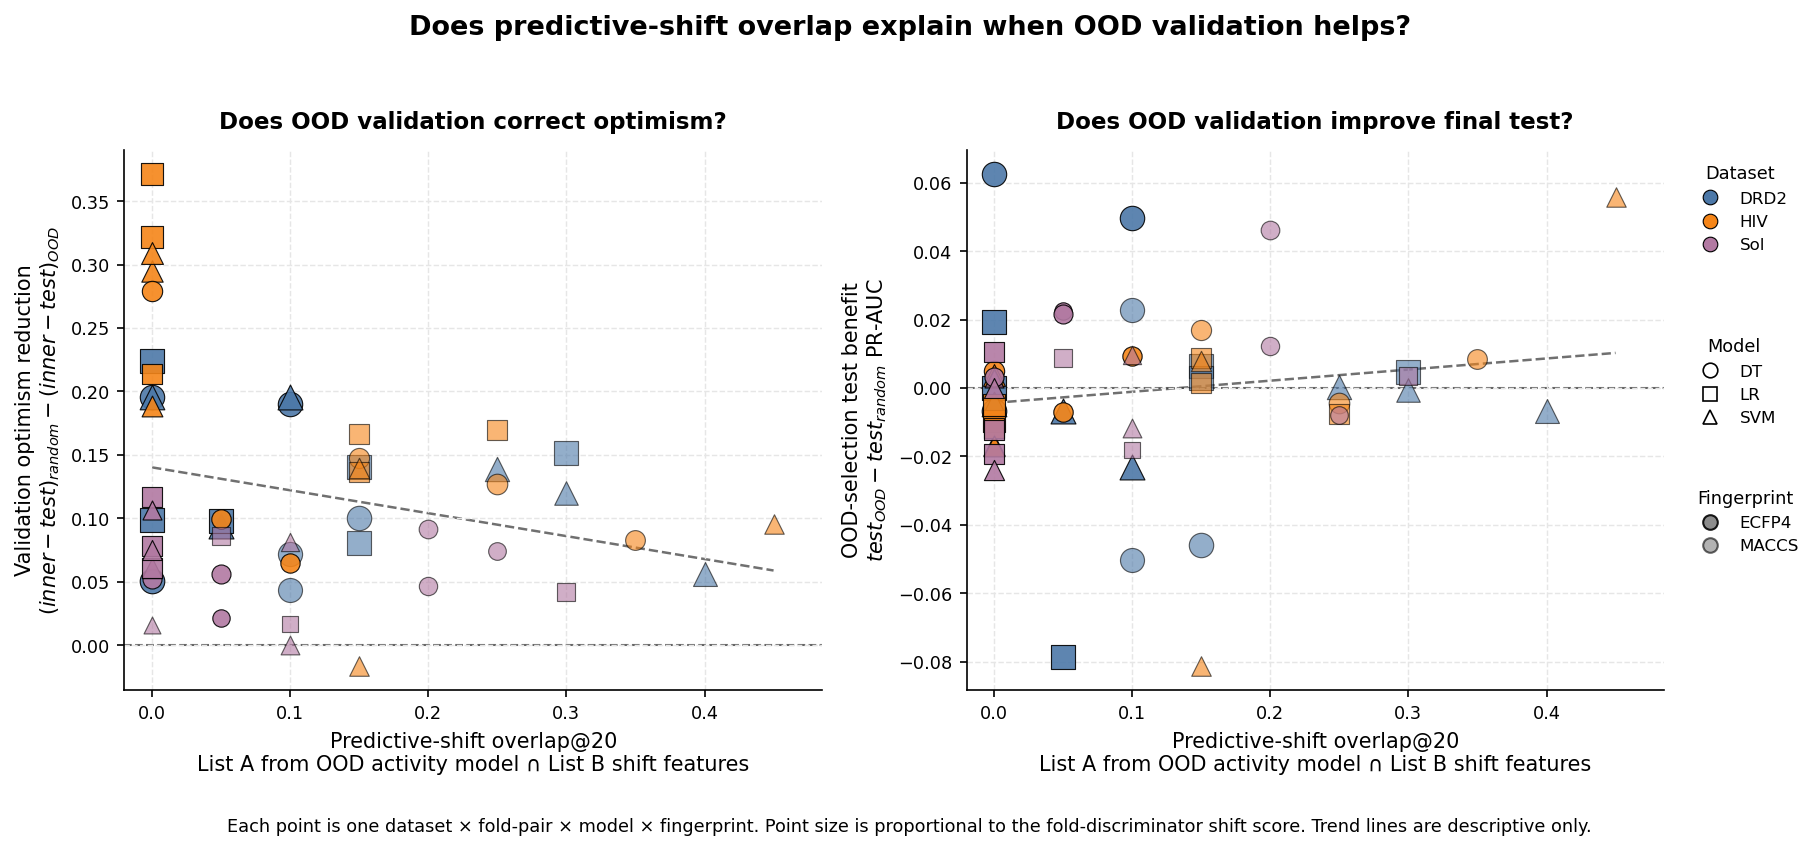

In [29]:
def add_trend_line(ax, x, y, color="0.25"):
    """
    Add a simple least-squares trend line if enough finite points exist.
    This is descriptive only, not a significance claim.
    """
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return

    x_valid = x[mask]
    y_valid = y[mask]

    coef = np.polyfit(x_valid, y_valid, deg=1)
    xx = np.linspace(x_valid.min(), x_valid.max(), 100)
    yy = coef[0] * xx + coef[1]

    ax.plot(
        xx,
        yy,
        color=color,
        linewidth=1.2,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )


def plot_predictive_shift_overlap_vs_protocol_gap(
    df: pd.DataFrame,
    x_col: str = "overlap_ood",
):
    """
    Plot whether List A/List B overlap explains:

    1. how much OOD validation reduces validation optimism;
    2. whether OOD model selection improves final OOD test performance.

    Recommended x_col:
        overlap_ood:
            overlap between List B shift features and List A features from
            OOD-selected activity models.

        overlap_mean:
            average overlap between List B and activity features from both
            OOD and random protocols.
    """
    required = [
        "dataset", "dataset_label", "pair", "fingerprint", "model",
        x_col, "optimism_gap_diff", "test_gap", "shift_score_01",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in predictive-shift table: {missing}")

    plot_df = df.copy()
    plot_df = plot_df[np.isfinite(plot_df[x_col])].copy()

    if len(plot_df) == 0:
        print("No finite overlap values — skipping plot.")
        return

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8.5,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    })

    if x_col == "overlap_ood":
        x_label = (
            f"Predictive-shift overlap@{OVERLAP_K}\n"
            "List A from OOD activity model ∩ List B shift features"
        )
        suffix = "overlap_ood"
    elif x_col == "overlap_mean":
        x_label = (
            f"Predictive-shift overlap@{OVERLAP_K}\n"
            "Mean List A/List B overlap across OOD and random activity models"
        )
        suffix = "overlap_mean"
    else:
        x_label = f"{x_col}"
        suffix = x_col

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12.2, 5.0),
        sharex=True,
    )

    y_specs = [
        (
            "optimism_gap_diff",
            "Validation optimism reduction\n"
            r"$(inner-test)_{random} - (inner-test)_{OOD}$",
            "Does OOD validation correct optimism?",
        ),
        (
            "test_gap",
            "OOD-selection test benefit\n"
            r"$test_{OOD} - test_{random}$ PR-AUC",
            "Does OOD validation improve final test?",
        ),
    ]

    for ax, (y_col, y_label, title) in zip(axes, y_specs):
        for _, row in plot_df.iterrows():
            dataset = row["dataset"]
            model = row["model"]
            fp = row["fingerprint"]

            x = row[x_col]
            y = row[y_col]

            marker = MODEL_MARKER.get(model, "o")
            color = DATASET_COLOR.get(dataset, "gray")
            alpha = FP_ALPHA.get(fp, 0.75)

            size = 55 + 90 * np.nan_to_num(row.get("shift_score_01", 0.0))

            ax.scatter(
                x,
                y,
                s=size,
                marker=marker,
                facecolor=color,
                edgecolor="black",
                linewidth=0.55,
                alpha=alpha,
                zorder=3,
            )

        add_trend_line(
            ax,
            plot_df[x_col].to_numpy(dtype=float),
            plot_df[y_col].to_numpy(dtype=float),
        )

        ax.axhline(
            0,
            color="0.25",
            linestyle="--",
            linewidth=1.0,
            alpha=0.8,
            zorder=1,
        )

        ax.set_title(title, fontweight="bold", pad=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            color="0.90",
            zorder=0,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        x_min = max(-0.02, plot_df[x_col].min() - 0.035)
        x_max = min(1.02, plot_df[x_col].max() + 0.035)
        ax.set_xlim(x_min, x_max)

    # Descriptive correlations
    corr_rows = []

    for y_col, _, _ in y_specs:
        sub = plot_df[[x_col, y_col]].dropna()

        if len(sub) >= 3:
            pearson = sub[x_col].corr(sub[y_col], method="pearson")
            spearman = sub[x_col].corr(sub[y_col], method="spearman")
        else:
            pearson = np.nan
            spearman = np.nan

        corr_rows.append({
            "x": x_col,
            "y": y_col,
            "n": len(sub),
            "pearson": pearson,
            "spearman": spearman,
        })

    corr_df = pd.DataFrame(corr_rows)

    print("\nDescriptive correlations, not statistical claims:")
    display(corr_df.round(3))

    dataset_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.55,
            markersize=7,
            label=DATASET_LABELS.get(dataset, dataset.upper()),
        )
        for dataset, color in DATASET_COLOR.items()
    ]

    model_handles = [
        Line2D(
            [0], [0],
            marker=marker,
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.8,
            markersize=7,
            label=model,
        )
        for model, marker in MODEL_MARKER.items()
    ]

    fp_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor="gray",
            markeredgecolor="black",
            alpha=alpha,
            markersize=7,
            label=fp.upper(),
        )
        for fp, alpha in FP_ALPHA.items()
    ]

    legend_1 = axes[1].legend(
        handles=dataset_handles,
        title="Dataset",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=False,
    )
    axes[1].add_artist(legend_1)

    legend_2 = axes[1].legend(
        handles=model_handles,
        title="Model",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.68),
        frameon=False,
    )
    axes[1].add_artist(legend_2)

    axes[1].legend(
        handles=fp_handles,
        title="Fingerprint",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.40),
        frameon=False,
    )

    fig.suptitle(
        "Does predictive-shift overlap explain when OOD validation helps?",
        fontweight="bold",
        y=1.04,
        fontsize=13,
    )

    fig.text(
        0.5,
        -0.03,
        "Each point is one dataset × fold-pair × model × fingerprint. "
        "Point size is proportional to the fold-discriminator shift score. "
        "Trend lines are descriptive only.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    fig.tight_layout()

    fname_png = FIG_ROOT / f"predictive_shift_overlap_vs_protocol_gap_top{OVERLAP_K}_{suffix}.png"
    fname_pdf = FIG_ROOT / f"predictive_shift_overlap_vs_protocol_gap_top{OVERLAP_K}_{suffix}.pdf"

    fig.savefig(fname_png, dpi=600, bbox_inches="tight")
    fig.savefig(fname_pdf, bbox_inches="tight")

    print(f"Saved: {fname_png.name}")
    print(f"Saved: {fname_pdf.name}")

    plt.show()
    plt.close(fig)

    return corr_df


corr_overlap_ood = plot_predictive_shift_overlap_vs_protocol_gap(
    df_predictive_shift,
    x_col="overlap_ood",
)


Descriptive correlations, not statistical claims:


,x,y,n,pearson,spearman
0,overlap_mean,optimism_gap_diff,54,-0.244,-0.205
1,overlap_mean,test_gap,54,0.234,0.248


Saved: predictive_shift_overlap_vs_protocol_gap_top20_overlap_mean.png
Saved: predictive_shift_overlap_vs_protocol_gap_top20_overlap_mean.pdf


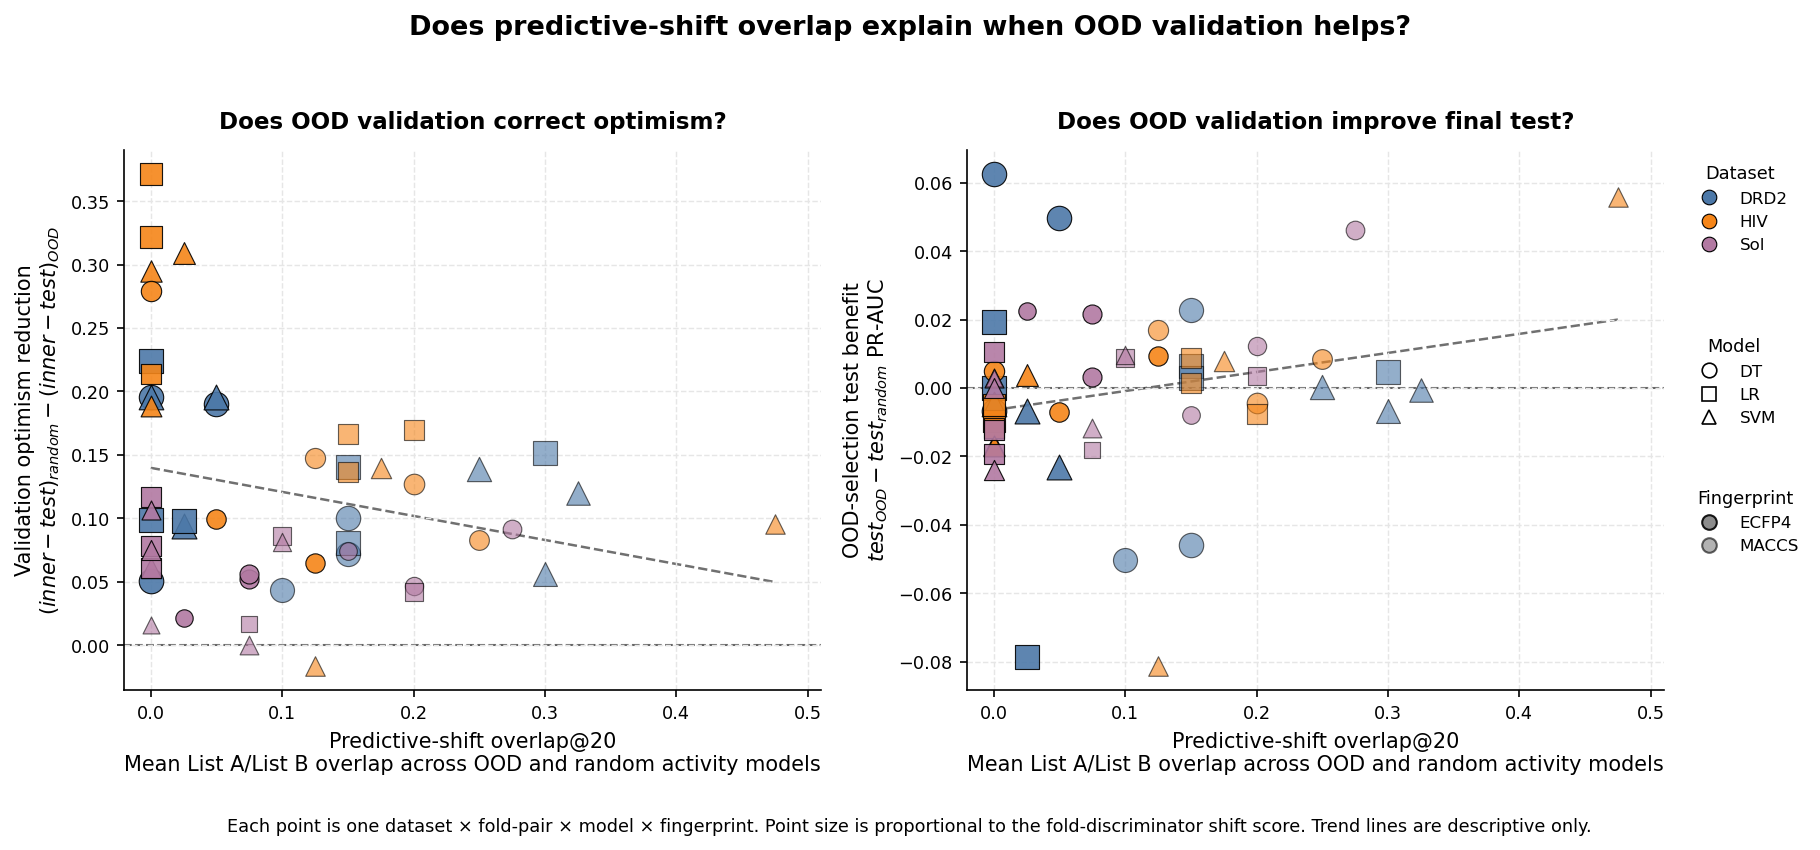

In [30]:
corr_overlap_mean = plot_predictive_shift_overlap_vs_protocol_gap(
    df_predictive_shift,
    x_col="overlap_mean",
)

In [31]:
# ============================================================
# Random-overlap baseline for List A vs List B
#
# Purpose:
#   Raw overlap is not directly comparable across fingerprints.
#   For example, top-20 overlap in MACCS is expected to be much higher
#   than top-20 overlap in ECFP4 simply because MACCS has fewer features.
#
# We therefore compute:
#   expected random overlap
#   enrichment = observed / expected
#   z-score vs hypergeometric random baseline
#   upper-tail p-value, used only descriptively
# ============================================================

import numpy as np
import pandas as pd

try:
    from scipy.stats import hypergeom
except Exception:
    hypergeom = None


FINGERPRINT_UNIVERSE_SIZE = {
    "ecfp4": 2048,
    "maccs": 167,
    "rdkit_desc": 217,  # approximate; change if your actual descriptor count differs
}


def infer_overlap_scale(df: pd.DataFrame, cols):
    """
    Detect whether overlap columns are fractions in [0, 1] or percentages in [0, 100].
    """
    vals = []

    for col in cols:
        if col in df.columns:
            vals.extend(df[col].dropna().astype(float).tolist())

    if len(vals) == 0:
        return "fraction"

    return "percent" if np.nanmax(vals) > 1.5 else "fraction"


def add_random_overlap_baseline(df: pd.DataFrame, k: int, overlap_cols=None):
    if overlap_cols is None:
        overlap_cols = ["overlap_ood", "overlap_random", "overlap_mean"]

    out = df.copy()

    scale = infer_overlap_scale(out, overlap_cols)

    if scale == "percent":
        for col in overlap_cols:
            if col in out.columns:
                out[f"{col}_frac"] = out[col] / 100.0
    else:
        for col in overlap_cols:
            if col in out.columns:
                out[f"{col}_frac"] = out[col].astype(float)

    out["fingerprint"] = out["fingerprint"].astype(str).str.lower()
    out["feature_universe_size"] = out["fingerprint"].map(FINGERPRINT_UNIVERSE_SIZE)

    missing_universe = out[out["feature_universe_size"].isna()]["fingerprint"].unique()

    if len(missing_universe) > 0:
        raise ValueError(
            f"Missing universe size for fingerprints: {missing_universe}. "
            "Add them to FINGERPRINT_UNIVERSE_SIZE."
        )

    out["effective_k"] = out["feature_universe_size"].clip(upper=k).astype(int)

    # Expected overlap fraction between two random top-k sets from universe U:
    # E[|A ∩ B| / k] = k / U
    out["random_overlap_expected_frac"] = (
        out["effective_k"] / out["feature_universe_size"]
    )

    for col in overlap_cols:
        frac_col = f"{col}_frac"

        if frac_col not in out.columns:
            continue

        obs_frac = out[frac_col].astype(float).clip(lower=0, upper=1)
        k_eff = out["effective_k"].astype(float)
        U = out["feature_universe_size"].astype(float)

        obs_count = np.rint(obs_frac * k_eff).astype(float)
        expected_count = (k_eff * k_eff) / U
        expected_frac = expected_count / k_eff

        # Hypergeometric variance:
        # X = |A ∩ B|, with A fixed size k, B sampled size k from U.
        # X ~ Hypergeom(M=U, n=k, N=k)
        var_count = (
            k_eff
            * (k_eff / U)
            * (1.0 - k_eff / U)
            * ((U - k_eff) / (U - 1.0))
        )

        sd_frac = np.sqrt(var_count) / k_eff

        out[f"{col}_random_expected_frac"] = expected_frac
        out[f"{col}_enrichment"] = obs_frac / expected_frac.replace(0, np.nan)
        out[f"{col}_z"] = (obs_frac - expected_frac) / sd_frac.replace(0, np.nan)
        out[f"{col}_observed_count"] = obs_count
        out[f"{col}_expected_count"] = expected_count

        if hypergeom is not None:
            pvals = []

            for _, row in out.iterrows():
                M = int(row["feature_universe_size"])
                kk = int(row["effective_k"])
                x = int(row[f"{col}_observed_count"])

                # P[X >= observed]
                p = hypergeom.sf(x - 1, M, kk, kk)
                pvals.append(p)

            out[f"{col}_p_upper_random"] = pvals
        else:
            out[f"{col}_p_upper_random"] = np.nan

    return out


df_predictive_shift_enriched = add_random_overlap_baseline(
    df_predictive_shift,
    k=OVERLAP_K,
    overlap_cols=["overlap_ood", "overlap_random", "overlap_mean"],
)

out_path = OUT_ROOT / f"cross_dataset_predictive_shift_overlap_enriched_top{OVERLAP_K}.csv"
df_predictive_shift_enriched.to_csv(out_path, index=False)

print(f"Saved: {out_path}")

cols_to_show = [
    "dataset", "pair", "fingerprint", "model",
    "overlap_ood_frac",
    "overlap_ood_random_expected_frac",
    "overlap_ood_enrichment",
    "overlap_ood_z",
    "optimism_gap_diff",
    "test_gap",
    "shift_score_01",
]

display(df_predictive_shift_enriched[cols_to_show].round(3).head(30))

Saved: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_predictive_shift_overlap_enriched_top20.csv


,dataset,pair,fingerprint,model,overlap_ood_frac,overlap_ood_random_expected_frac,overlap_ood_enrichment,overlap_ood_z,optimism_gap_diff,test_gap,shift_score_01
0,drd2,F1_vs_F2,ecfp4,DT,0.00,0.01,0.000,-0.446,0.051,-0.007,0.931
1,drd2,F1_vs_F2,ecfp4,LR,0.00,0.01,0.000,-0.446,0.099,0.019,0.977
2,drd2,F1_vs_F2,ecfp4,SVM,0.05,0.01,5.120,1.838,0.094,-0.007,0.977
3,drd2,F1_vs_F2,maccs,DT,0.10,0.12,0.835,-0.289,0.071,0.023,0.885
4,drd2,F1_vs_F2,maccs,LR,0.15,0.12,1.253,0.443,0.080,0.006,0.853
5,drd2,F1_vs_F2,maccs,SVM,0.40,0.12,3.340,4.102,0.056,-0.007,0.857
6,drd2,F1_vs_F3,ecfp4,DT,0.00,0.01,0.000,-0.446,0.196,0.062,0.909
7,drd2,F1_vs_F3,ecfp4,LR,0.00,0.01,0.000,-0.446,0.224,0.000,0.937
8,drd2,F1_vs_F3,ecfp4,SVM,0.00,0.01,0.000,-0.446,0.195,-0.005,0.941
9,drd2,F1_vs_F3,maccs,DT,0.10,0.12,0.835,-0.289,0.044,-0.050,0.868


In [32]:
# ============================================================
# Aggregate to dataset × fold-pair level
#
# This is the clean paper-level version.
# It averages over model/fingerprint families and keeps:
#   structural shift
#   predictive-shift overlap enrichment
#   validation optimism reduction
#   OOD test benefit
# ============================================================

def aggregate_predictive_shift_for_paper(df: pd.DataFrame):
    work = df.copy()

    required = [
        "dataset", "pair",
        "shift_score_01",
        "overlap_ood_enrichment",
        "overlap_mean_enrichment",
        "overlap_ood_z",
        "overlap_mean_z",
        "optimism_gap_diff",
        "test_gap",
    ]

    missing = [c for c in required if c not in work.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    agg = (
        work
        .groupby(["dataset", "pair"], as_index=False)
        .agg(
            shift_score_mean=("shift_score_01", "mean"),
            shift_score_max=("shift_score_01", "max"),

            overlap_ood_mean=("overlap_ood_frac", "mean"),
            overlap_mean_mean=("overlap_mean_frac", "mean"),

            overlap_ood_enrichment_mean=("overlap_ood_enrichment", "mean"),
            overlap_mean_enrichment_mean=("overlap_mean_enrichment", "mean"),

            overlap_ood_z_mean=("overlap_ood_z", "mean"),
            overlap_mean_z_mean=("overlap_mean_z", "mean"),

            optimism_gap_diff_mean=("optimism_gap_diff", "mean"),
            test_gap_mean=("test_gap", "mean"),

            n_rows=("test_gap", "size"),
        )
    )

    agg["dataset_label"] = (
        agg["dataset"]
        .map(DATASET_LABELS)
        .fillna(agg["dataset"].astype(str).str.upper())
    )

    pair_label_map = {
        "F1_vs_F2": "F1–F2",
        "F1_vs_F3": "F1–F3",
        "F2_vs_F3": "F2–F3",
    }

    agg["pair_label"] = agg["pair"].map(pair_label_map).fillna(agg["pair"])

    return agg


df_predictive_shift_pair = aggregate_predictive_shift_for_paper(
    df_predictive_shift_enriched
)

out_path = OUT_ROOT / f"pair_level_predictive_shift_summary_top{OVERLAP_K}.csv"
df_predictive_shift_pair.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
display(df_predictive_shift_pair.round(3))

Saved: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/pair_level_predictive_shift_summary_top20.csv


,dataset,pair,shift_score_mean,shift_score_max,overlap_ood_mean,overlap_mean_mean,overlap_ood_enrichment_mean,overlap_mean_enrichment_mean,overlap_ood_z_mean,overlap_mean_z_mean,optimism_gap_diff_mean,test_gap_mean,n_rows,dataset_label,pair_label
0,drd2,F1_vs_F2,0.913,0.977,0.117,0.104,1.758,1.262,0.867,0.555,0.075,0.005,6,DRD2,F1–F2
1,drd2,F1_vs_F3,0.879,0.941,0.117,0.121,0.974,1.009,0.608,0.669,0.155,0.002,6,DRD2,F1–F3
2,drd2,F2_vs_F3,0.926,0.971,0.133,0.112,5.032,2.899,2.146,1.194,0.144,-0.016,6,DRD2,F2–F3
3,hiv,F1_vs_F2,0.437,0.554,0.083,0.075,1.480,1.410,0.379,0.257,0.169,-0.015,6,HIV,F1–F2
4,hiv,F1_vs_F3,0.404,0.492,0.175,0.167,3.029,3.351,1.979,1.987,0.130,0.008,6,HIV,F1–F3
5,hiv,F2_vs_F3,0.506,0.610,0.108,0.100,0.905,1.227,0.486,0.494,0.232,-0.000,6,HIV,F2–F3
6,sol,F1_vs_F2,0.203,0.318,0.067,0.042,1.340,0.740,0.135,-0.360,0.058,0.002,6,Sol,F1–F2
7,sol,F1_vs_F3,0.334,0.436,0.100,0.092,0.835,1.941,0.364,0.630,0.046,-0.006,6,Sol,F1–F3
8,sol,F2_vs_F3,0.317,0.419,0.067,0.092,1.340,1.941,0.135,0.630,0.075,0.012,6,Sol,F2–F3


Saved: structural_vs_predictive_shift_relevance_top20_overlap_enrichment.png
Saved: structural_vs_predictive_shift_relevance_top20_overlap_enrichment.pdf


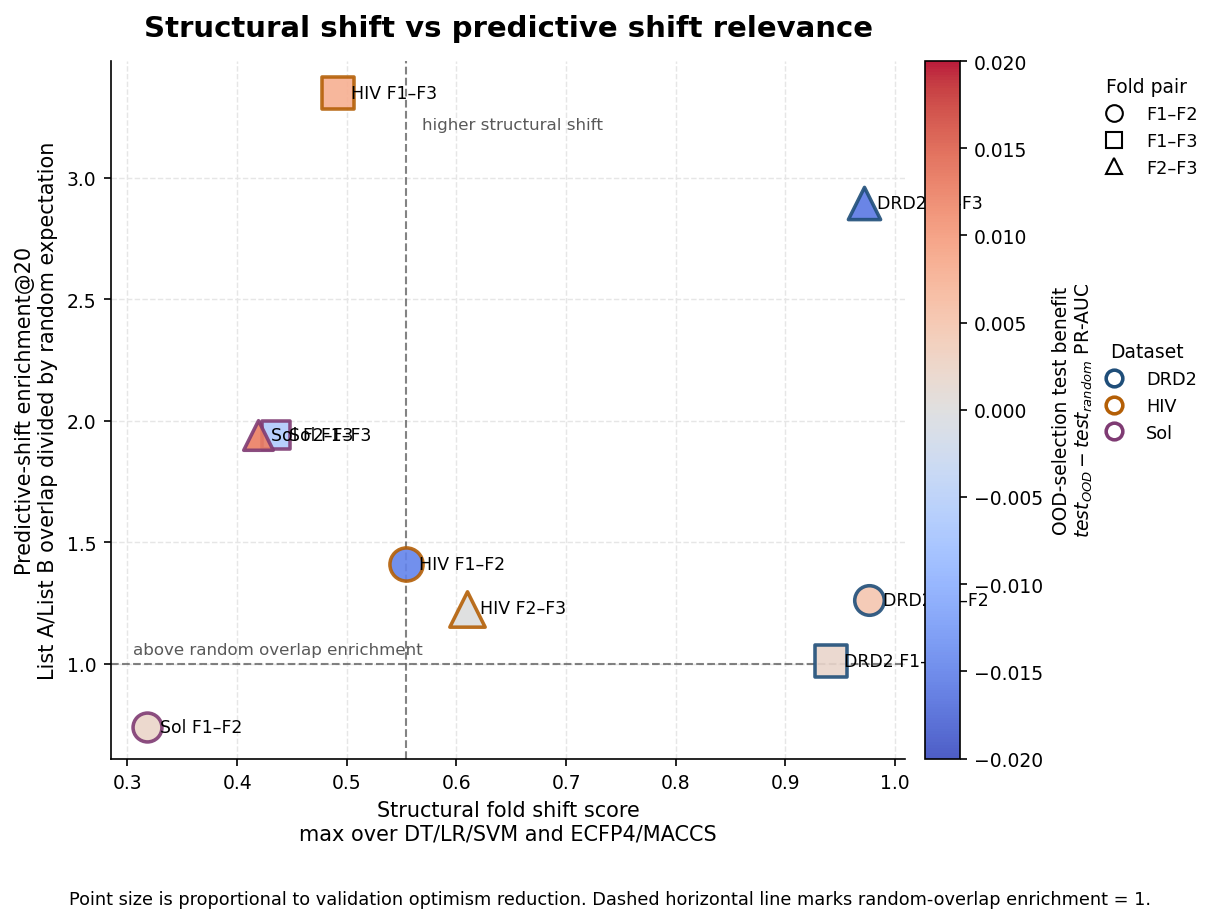

In [33]:
# ============================================================
# Paper-level quadrant plot:
# structural shift vs predictive-shift enrichment
#
# Color:
#   OOD test benefit
#
# Interpretation:
#   High structural shift + low predictive enrichment:
#       structural OOD, but not strongly predictive-OOD.
#
#   High structural shift + high predictive enrichment:
#       OOD split is more likely to matter for model selection.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D


PAIR_MARKER = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

DATASET_EDGE_COLOR = {
    "drd2": "#1f4e79",
    "hiv": "#b45f06",
    "sol": "#7f3b73",
}


def plot_structural_vs_predictive_shift(df_pair: pd.DataFrame, y_col="overlap_mean_enrichment_mean"):
    required = [
        "dataset", "dataset_label", "pair", "pair_label",
        "shift_score_max", y_col, "test_gap_mean", "optimism_gap_diff_mean",
    ]

    missing = [c for c in required if c not in df_pair.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df_pair.copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=["shift_score_max", y_col, "test_gap_mean"])

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.dpi": 600,
        "axes.linewidth": 0.8,
    })

    fig, ax = plt.subplots(figsize=(8.2, 5.8))

    vmax = max(abs(plot_df["test_gap_mean"].min()), abs(plot_df["test_gap_mean"].max()))
    vmax = max(vmax, 0.02)

    sc_handles = []

    for _, row in plot_df.iterrows():
        dataset = row["dataset"]
        pair = row["pair"]

        marker = PAIR_MARKER.get(pair, "o")
        edge = DATASET_EDGE_COLOR.get(dataset, "black")

        size = 160 + 550 * max(row["optimism_gap_diff_mean"], 0)

        sc = ax.scatter(
            row["shift_score_max"],
            row[y_col],
            c=row["test_gap_mean"],
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
            s=size,
            marker=marker,
            edgecolor=edge,
            linewidth=1.7,
            alpha=0.90,
            zorder=3,
        )

        ax.text(
            row["shift_score_max"] + 0.012,
            row[y_col],
            f"{row['dataset_label']} {row['pair_label']}",
            fontsize=8.3,
            ha="left",
            va="center",
        )

    # Reference lines
    x_med = plot_df["shift_score_max"].median()
    y_one = 1.0

    ax.axvline(
        x_med,
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        alpha=0.75,
    )

    ax.axhline(
        y_one,
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        alpha=0.75,
    )

    ax.text(
        x_med + 0.015,
        ax.get_ylim()[1] * 0.92,
        "higher structural shift",
        fontsize=8,
        color="0.35",
        ha="left",
    )

    ax.text(
        ax.get_xlim()[0] + 0.02,
        y_one + 0.04,
        "above random overlap enrichment",
        fontsize=8,
        color="0.35",
        ha="left",
    )

    ax.set_xlabel(
        "Structural fold shift score\n"
        "max over DT/LR/SVM and ECFP4/MACCS"
    )

    ax.set_ylabel(
        f"Predictive-shift enrichment@{OVERLAP_K}\n"
        "List A/List B overlap divided by random expectation"
    )

    ax.set_title(
        "Structural shift vs predictive shift relevance",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        color="0.90",
        zorder=0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(
        "OOD-selection test benefit\n"
        r"$test_{OOD} - test_{random}$ PR-AUC",
        fontsize=9,
    )

    pair_handles = [
        Line2D(
            [0], [0],
            marker=marker,
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label=label,
        )
        for pair, marker in PAIR_MARKER.items()
        for label in [pair.replace("_vs_", "–")]
    ]

    dataset_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.7,
            markersize=8,
            label=DATASET_LABELS.get(dataset, dataset.upper()),
        )
        for dataset, color in DATASET_EDGE_COLOR.items()
    ]

    legend_1 = ax.legend(
        handles=pair_handles,
        title="Fold pair",
        loc="upper left",
        bbox_to_anchor=(1.22, 1.00),
        frameon=False,
    )

    ax.add_artist(legend_1)

    ax.legend(
        handles=dataset_handles,
        title="Dataset",
        loc="upper left",
        bbox_to_anchor=(1.22, 0.62),
        frameon=False,
    )

    fig.text(
        0.5,
        -0.03,
        "Point size is proportional to validation optimism reduction. "
        "Dashed horizontal line marks random-overlap enrichment = 1.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    fig.tight_layout()

    suffix = y_col.replace("_mean", "")
    fname_png = FIG_ROOT / f"structural_vs_predictive_shift_relevance_top{OVERLAP_K}_{suffix}.png"
    fname_pdf = FIG_ROOT / f"structural_vs_predictive_shift_relevance_top{OVERLAP_K}_{suffix}.pdf"

    fig.savefig(fname_png, dpi=600, bbox_inches="tight")
    fig.savefig(fname_pdf, bbox_inches="tight")

    print(f"Saved: {fname_png.name}")
    print(f"Saved: {fname_pdf.name}")

    plt.show()
    plt.close(fig)


plot_structural_vs_predictive_shift(
    df_predictive_shift_pair,
    y_col="overlap_mean_enrichment_mean",
)

In [34]:
# ============================================================
# Predictor comparison:
# does predictive-shift relevance explain OOD benefit better
# than structural shift alone?
#
# This is descriptive only, because n=9 pair-level points.
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut


def spearman_safe(x, y):
    sub = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()

    if len(sub) < 3:
        return np.nan

    return sub["x"].corr(sub["y"], method="spearman")


def loo_r2(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(X).all(axis=1) & np.isfinite(y)

    X = X[mask]
    y = y[mask]

    if len(y) < 4:
        return np.nan

    loo = LeaveOneOut()
    preds = np.zeros_like(y, dtype=float)

    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])

    return r2_score(y, preds)


def compare_predictors_for_ood_benefit(df_pair: pd.DataFrame):
    work = df_pair.copy()
    work = work.replace([np.inf, -np.inf], np.nan)

    work["interaction_shift_x_enrichment"] = (
        work["shift_score_max"] * work["overlap_mean_enrichment_mean"]
    )

    y = work["test_gap_mean"].to_numpy(dtype=float)

    predictors = {
        "structural_shift_only": ["shift_score_max"],
        "predictive_overlap_only": ["overlap_mean_enrichment_mean"],
        "predictive_overlap_z_only": ["overlap_mean_z_mean"],
        "shift_plus_overlap": ["shift_score_max", "overlap_mean_enrichment_mean"],
        "shift_x_overlap_interaction": ["interaction_shift_x_enrichment"],
        "shift_plus_overlap_plus_interaction": [
            "shift_score_max",
            "overlap_mean_enrichment_mean",
            "interaction_shift_x_enrichment",
        ],
    }

    rows = []

    for name, cols in predictors.items():
        sub = work[cols + ["test_gap_mean"]].dropna()

        if len(sub) < 4:
            rows.append({
                "predictor_set": name,
                "n": len(sub),
                "in_sample_r2": np.nan,
                "loo_r2": np.nan,
                "spearman_first_predictor": np.nan,
            })
            continue

        X = sub[cols].to_numpy(dtype=float)
        yy = sub["test_gap_mean"].to_numpy(dtype=float)

        model = LinearRegression()
        model.fit(X, yy)

        pred = model.predict(X)

        rows.append({
            "predictor_set": name,
            "predictors": ", ".join(cols),
            "n": len(sub),
            "in_sample_r2": r2_score(yy, pred),
            "loo_r2": loo_r2(X, yy),
            "spearman_first_predictor": spearman_safe(sub[cols[0]], sub["test_gap_mean"]),
            "coef": model.coef_.tolist(),
            "intercept": model.intercept_,
        })

    out = pd.DataFrame(rows)

    return out


df_predictor_comparison = compare_predictors_for_ood_benefit(
    df_predictive_shift_pair
)

out_path = OUT_ROOT / f"predictor_comparison_ood_benefit_top{OVERLAP_K}.csv"
df_predictor_comparison.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
display(df_predictor_comparison.round(3))

Saved: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/predictor_comparison_ood_benefit_top20.csv


,predictor_set,predictors,n,in_sample_r2,loo_r2,spearman_first_predictor,coef,intercept
0,structural_shift_only,shift_score_max,9,0.068,-0.561,-0.333,[-0.009639974854049868],0.005
1,predictive_overlap_only,overlap_mean_enrichment_mean,9,0.006,-0.962,0.033,[-0.0008532063420576755],0.001
2,predictive_overlap_z_only,overlap_mean_z_mean,9,0.011,-0.808,0.150,[0.0015522014110736836],-0.002
3,shift_plus_overlap,"shift_score_max, overlap_mean_enrichment_mean",9,0.073,-1.350,-0.333,"[-0.009573470020304573, -0.0007819602455084757]",0.007
4,shift_x_overlap_interaction,interaction_shift_x_enrichment,9,0.141,-1.171,-0.033,[-0.00487803293821648],0.005
5,shift_plus_overlap_plus_interaction,"shift_score_max, overlap_mean_enrichment_mean,...",9,0.396,-0.859,-0.333,"[0.03184556237807224, 0.015014390771239396, -0...",-0.019


Saved: predictors_of_ood_test_benefit_top20.png
Saved: predictors_of_ood_test_benefit_top20.pdf


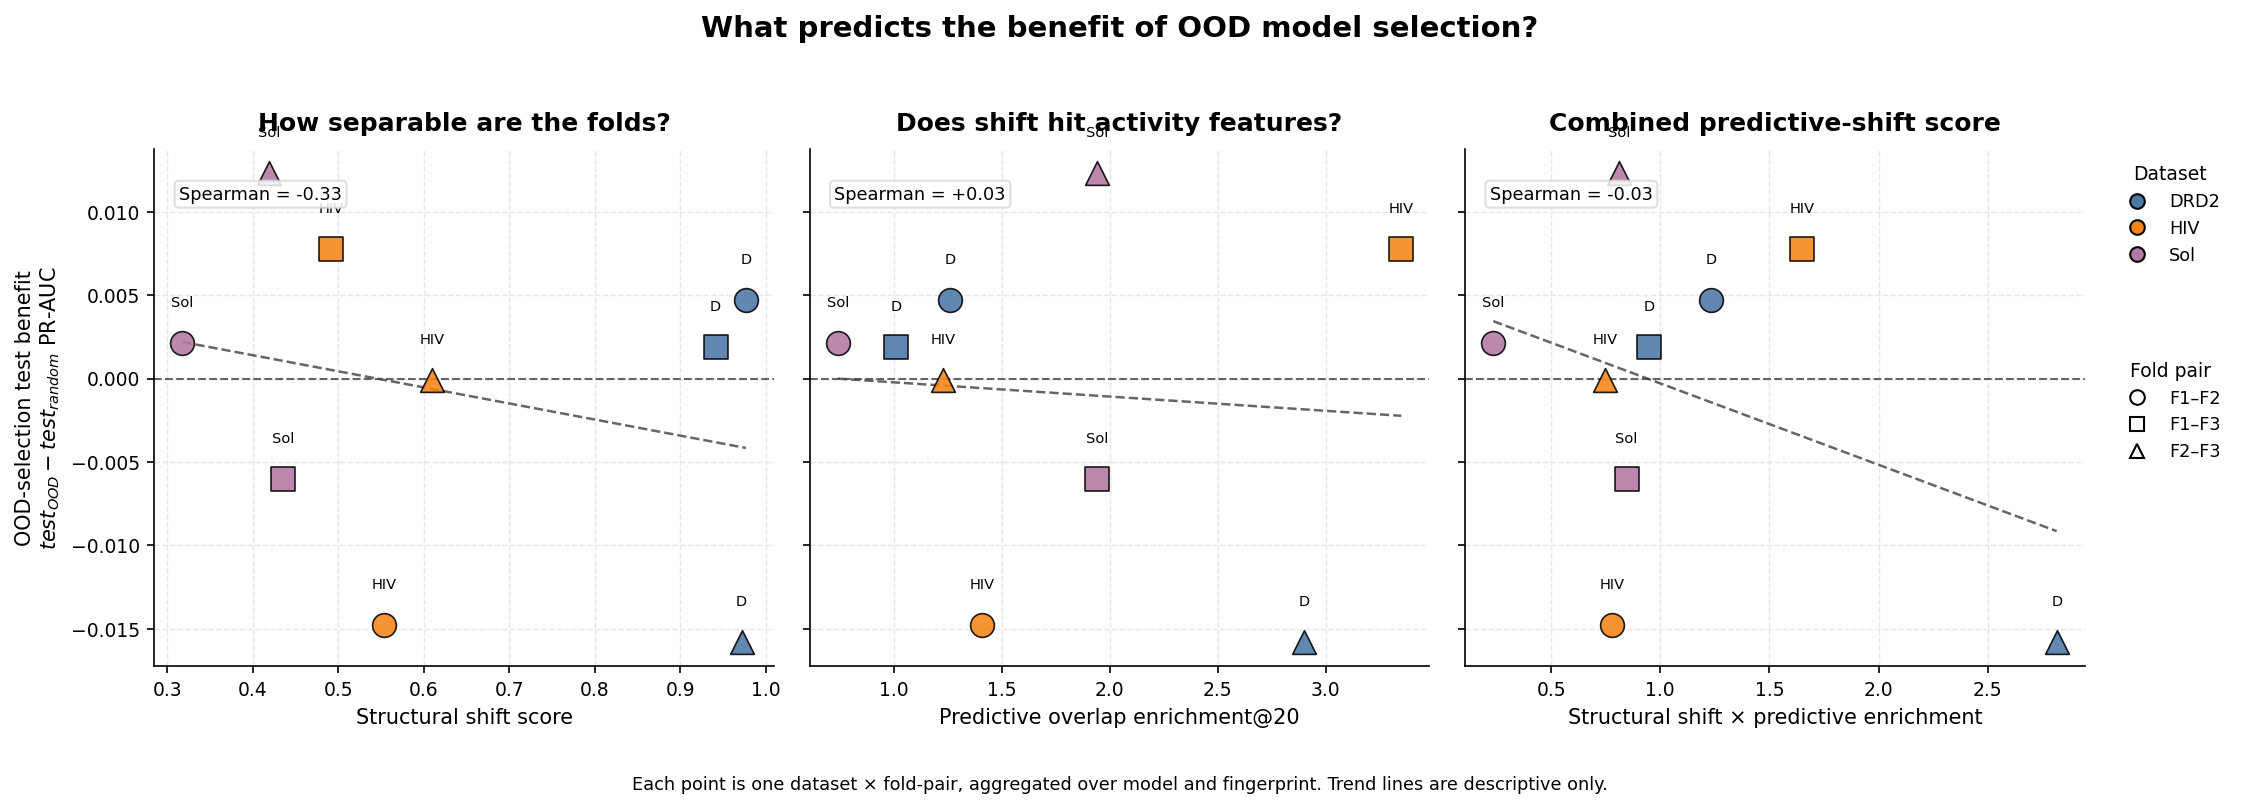

In [35]:
# ============================================================
# Three-panel diagnostic:
#   1. structural shift vs OOD benefit
#   2. predictive overlap enrichment vs OOD benefit
#   3. interaction vs OOD benefit
# ============================================================

def plot_predictor_panels(df_pair: pd.DataFrame):
    work = df_pair.copy()
    work = work.replace([np.inf, -np.inf], np.nan)

    work["interaction_shift_x_enrichment"] = (
        work["shift_score_max"] * work["overlap_mean_enrichment_mean"]
    )

    specs = [
        (
            "shift_score_max",
            "Structural shift score",
            "How separable are the folds?",
        ),
        (
            "overlap_mean_enrichment_mean",
            f"Predictive overlap enrichment@{OVERLAP_K}",
            "Does shift hit activity features?",
        ),
        (
            "interaction_shift_x_enrichment",
            "Structural shift × predictive enrichment",
            "Combined predictive-shift score",
        ),
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15.0, 4.7),
        sharey=True,
    )

    for ax, (x_col, x_label, title) in zip(axes, specs):
        sub = work.dropna(subset=[x_col, "test_gap_mean"]).copy()

        for _, row in sub.iterrows():
            ax.scatter(
                row[x_col],
                row["test_gap_mean"],
                s=130,
                marker=PAIR_MARKER.get(row["pair"], "o"),
                facecolor=DATASET_COLOR.get(row["dataset"], "gray"),
                edgecolor="black",
                linewidth=0.8,
                alpha=0.88,
                zorder=3,
            )

            ax.text(
                row[x_col],
                row["test_gap_mean"] + 0.002,
                row["dataset_label"].replace("DRD2", "D"),
                fontsize=7,
                ha="center",
                va="bottom",
            )

        mask = np.isfinite(sub[x_col]) & np.isfinite(sub["test_gap_mean"])

        if mask.sum() >= 3:
            x = sub.loc[mask, x_col].to_numpy(dtype=float)
            y = sub.loc[mask, "test_gap_mean"].to_numpy(dtype=float)

            coef = np.polyfit(x, y, deg=1)
            xx = np.linspace(x.min(), x.max(), 100)
            yy = coef[0] * xx + coef[1]

            ax.plot(
                xx,
                yy,
                color="0.25",
                linestyle="--",
                linewidth=1.2,
                alpha=0.8,
            )

            spearman = pd.Series(x).corr(pd.Series(y), method="spearman")
            ax.text(
                0.04,
                0.93,
                f"Spearman = {spearman:+.2f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8.5,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="0.85",
                    alpha=0.85,
                ),
            )

        ax.axhline(
            0,
            color="0.25",
            linestyle="--",
            linewidth=1.0,
            alpha=0.8,
        )

        ax.set_title(title, fontweight="bold", pad=9)
        ax.set_xlabel(x_label)
        ax.grid(True, linestyle="--", linewidth=0.7, color="0.90")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(
        "OOD-selection test benefit\n"
        r"$test_{OOD} - test_{random}$ PR-AUC"
    )

    pair_handles = [
        Line2D(
            [0], [0],
            marker=marker,
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=7,
            label=pair.replace("_vs_", "–"),
        )
        for pair, marker in PAIR_MARKER.items()
    ]

    dataset_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=7,
            label=DATASET_LABELS.get(dataset, dataset.upper()),
        )
        for dataset, color in DATASET_COLOR.items()
    ]

    legend_1 = axes[-1].legend(
        handles=dataset_handles,
        title="Dataset",
        loc="upper left",
        bbox_to_anchor=(1.03, 1.00),
        frameon=False,
    )

    axes[-1].add_artist(legend_1)

    axes[-1].legend(
        handles=pair_handles,
        title="Fold pair",
        loc="upper left",
        bbox_to_anchor=(1.03, 0.62),
        frameon=False,
    )

    fig.suptitle(
        "What predicts the benefit of OOD model selection?",
        fontsize=14,
        fontweight="bold",
        y=1.04,
    )

    fig.text(
        0.5,
        -0.04,
        "Each point is one dataset × fold-pair, aggregated over model and fingerprint. "
        "Trend lines are descriptive only.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    fig.tight_layout()

    fname_png = FIG_ROOT / f"predictors_of_ood_test_benefit_top{OVERLAP_K}.png"
    fname_pdf = FIG_ROOT / f"predictors_of_ood_test_benefit_top{OVERLAP_K}.pdf"

    fig.savefig(fname_png, dpi=600, bbox_inches="tight")
    fig.savefig(fname_pdf, bbox_inches="tight")

    print(f"Saved: {fname_png.name}")
    print(f"Saved: {fname_pdf.name}")

    plt.show()
    plt.close(fig)


plot_predictor_panels(df_predictive_shift_pair)